# DocVQA Document Visual Question Answering Benchmark Analysis

Executive Summary

**Dataset:** DocVQA_mini - Document Visual Question Answering  
**Total Samples:** 500 document Q&A pairs per phase  
**Task:** Answer questions about document images  
**Evaluation Metrics:** GT in Pred (PRIMARY), ANLS, Exact Match, Substring Match, Cosine Similarity

## Benchmark Structure

### $QA_{\text{OCR}}$: OCR parsing → LLM QA
**Strategy:** Separate OCR extraction → LLM answers question based on extracted text

- **$QA_{\text{OCR}}^{\text{simple}}$:** Azure Intelligence OCR + GPT-5-mini QA (simple prompt)
- **$QA_{\text{OCR}}^{\text{generic}}$:** Mistral OCR 2 OCR + GPT-5-mini QA (generic prompt)
- **$QA_{\text{OCR}}^{\text{task-aware}}$:** Azure Intelligence OCR + GPT-5-mini QA (task-aware prompt)

**Model Format:** `{parsing_model}__{qa_model}` (e.g., `azure_intelligence__gpt-5-mini`)

### $QA_{\text{VLM-2stage}}$: VLM parsing → LLM QA
**Strategy:** Same VLM does both parsing and question answering

- **$QA_{\text{VLM-2stage}}^{\text{cot}}$:** GPT-5-mini does parsing + QA (CoT prompt)
- **$QA_{\text{VLM-2stage}}^{\text{generic+cot}}$:** GPT-5-nano does parsing + QA (generic + CoT)
- **$QA_{\text{VLM-2stage}}^{\text{sonnet}}$:** Claude Sonnet does parsing + QA

**Model Format:** `{model}__{model}` (e.g., `claude_sonnet__claude_sonnet`)

### $QA_{\text{VLM-direct}}$: Direct VLM QA
**Strategy:** VLM sees image directly and answers question

- **$QA_{\text{VLM-direct}}^{\text{sonnet}}$:** Claude Sonnet direct VQA
- **$QA_{\text{VLM-direct}}^{\text{multi}}$:** GPT-5-mini, GPT-5-nano, Claude Sonnet direct VQA

# 1. Imports and Metadata

In [1]:
# Required imports
import sys
from pathlib import Path
from typing import List, Dict, Any, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Add parent directories to path for imports
sys.path.insert(0, str(Path("../../../..").resolve()))

# Import metrics functions
from ocr_vs_vlm.metrics.evaluation_metrics import (
    compute_anls,
    compute_exact_match,
    compute_substring_match,
    compute_ground_truth_in_prediction,
    compute_prediction_in_ground_truth,
    parse_ground_truths
)
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Set display options
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.dpi'] = 100

# Color palette for visualizations
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'mistral_ocr_3', 'donut', 
               'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        # Extract base model name (remove __ suffix for QA1/QA2 phases)
        base_model = model.split('__')[-1] if '__' in model else model
        try:
            return MODEL_ORDER.index(base_model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral OCR 2',
        'mistral_ocr_3': 'Mistral OCR 3',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    # Handle composite model names (e.g., azure_intelligence__gpt-5-mini)
    if '__' in model:
        parts = model.split('__')
        return f"{display_names.get(parts[0], parts[0])} → {display_names.get(parts[1], parts[1])}"
    return display_names.get(model, model)


def get_phase_group(phase: str) -> str:
    """Get phase group with formal notation."""
    if phase.startswith('QA1'):
        return '$QA_{\\text{OCR}}$'
    elif phase.startswith('QA2'):
        return '$QA_{\\text{VLM-2stage}}$'
    elif phase.startswith('QA3'):
        return '$QA_{\\text{VLM-direct}}$'
    elif phase.startswith('QA4'):
        return '$QA_{\\text{special}}$'
    return 'Unknown'

def get_phase_formal_name(phase: str) -> str:
    """Get formal mathematical name for a specific phase."""
    phase_mapping = {
        'QA1a': '$QA_{\\text{OCR}}^{\\text{simple}}$',
        'QA1b': '$QA_{\\text{OCR}}^{\\text{generic}}$',
        'QA1c': '$QA_{\\text{OCR}}^{\\text{task-aware}}$',
        'QA2a': '$QA_{\\text{VLM-2stage}}^{\\text{cot}}$',
        'QA2b': '$QA_{\\text{VLM-2stage}}^{\\text{generic+cot}}$',
        'QA2c': '$QA_{\\text{VLM-2stage}}^{\\text{sonnet}}$',
        'QA3a': '$QA_{\\text{VLM-direct}}^{\\text{sonnet}}$',
        'QA3b': '$QA_{\\text{VLM-direct}}^{\\text{multi}}$',
    }
    return phase_mapping.get(phase, phase)

def get_phase_strategy(phase: str) -> str:
    """Alias for get_phase_group for consistency."""
    return get_phase_group(phase)

def categorize_question_type(question: str) -> str:
    """Categorize question by type based on question words."""
    question_lower = question.lower().strip()
    
    if question_lower.startswith('what'):
        return 'What'
    elif question_lower.startswith('who'):
        return 'Who'
    elif question_lower.startswith('where'):
        return 'Where'
    elif question_lower.startswith('when'):
        return 'When'
    elif question_lower.startswith('how many') or question_lower.startswith('how much'):
        return 'How many/much'
    elif question_lower.startswith('how'):
        return 'How'
    elif question_lower.startswith('which'):
        return 'Which'
    elif question_lower.startswith('is') or question_lower.startswith('are') or question_lower.startswith('does') or question_lower.startswith('do'):
        return 'Yes/No'
    else:
        return 'Other'

## 2. Dataset Explorer

Load all phase files and explore the DocVQA dataset structure.

In [2]:
# Define paths
RESULTS_DIR = Path("../../2_clean/DocVQA_mini")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - QA1a.csv
  - QA1b.csv
  - QA1c.csv
  - QA2a.csv
  - QA2b.csv
  - QA2c.csv
  - QA3a.csv
  - QA3b.csv


In [3]:
# Dataset configuration
DATASET_NAME = "DocVQA_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: DocVQA_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: QA2b, QA1c, QA1a, QA3b, QA3a, QA1b, QA2a, QA2c


In [4]:
# Load results for each phase
phase_dfs = {}

# Standard QA phases
STANDARD_PHASES = ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA3a', 'QA3b']

for phase in STANDARD_PHASES:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

QA1a: 500 samples, 16 columns
QA1b: 500 samples, 16 columns
QA1c: 500 samples, 16 columns
QA2a: 500 samples, 16 columns
QA2b: 500 samples, 16 columns
QA3a: 500 samples, 12 columns
QA3b: 500 samples, 16 columns

Total phases loaded: 7


In [5]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Question column: {'question' if 'question' in df.columns else 'NOT FOUND'}")
    print(f"  Ground truths column: {'ground_truths' if 'ground_truths' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


QA1a columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA1b columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA1c columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2a columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2b columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA3a columns:
  M

### Quality assessment

In [6]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 QA1a - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 489/500 (97.8%)
    ⚠️  Empty predictions: 11
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 493/500 (98.6%)
    ⚠️  Empty predictions: 7
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 493/500 (98.6%)
    ⚠️  Empty predictions: 7

📊 QA1b - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 493/500 (98.6%)
    ⚠️  Empty predictions: 7
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 497/500 (99.4%)
    ⚠️  Empty predictions: 3
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 497/500 (99.4%)
    ⚠️  Empty predictions: 3

📊 QA1c - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 490/500 (98.0%)
    ⚠️  Empty predictions: 10
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 495/500 (99.0%)
    ⚠️  Empty predictions: 5
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 492/500 (98.4%)
    ⚠️  Empty predictions: 8

📊 QA2a - Total rows: 500
  claude_

,Phase,Model,Total Rows,Valid Rows,Empty Predictions,Errors,Valid %
0,QA1a,azure_intelligence__gpt-5-mini,500,489,11,0,97.8
11,QA2a,gpt-5-nano__gpt-5-nano,500,489,11,0,97.8
14,QA2b,gpt-5-nano__gpt-5-nano,500,489,11,0,97.8
6,QA1c,azure_intelligence__gpt-5-mini,500,490,10,0,98.0
8,QA1c,mistral_ocr_3__gpt-5-mini,500,492,8,0,98.4
1,QA1a,mistral_document_ai__gpt-5-mini,500,493,7,0,98.6
2,QA1a,mistral_ocr_3__gpt-5-mini,500,493,7,0,98.6
3,QA1b,azure_intelligence__gpt-5-mini,500,493,7,0,98.6
7,QA1c,mistral_document_ai__gpt-5-mini,500,495,5,0,99.0
4,QA1b,mistral_document_ai__gpt-5-mini,500,497,3,0,99.4



⚠️  Found 16 model-phase combinations with data quality issues
These rows will be EXCLUDED from all metric calculations



## 2.5 Data Quality Assessment ⚠️

**Critical Step:** Identify and filter out rows with empty predictions or errors to ensure accurate metrics.

# 3. Dataset Statistics

Analyze question and answer characteristics.

In [7]:
# Basic statistics for first available phase
phase_to_display = list(phase_dfs.keys())[0] if phase_dfs else None

if phase_to_display:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'question' in df_base.columns:
        # Question length statistics
        question_lengths = df_base['question'].astype(str).str.len()
        question_word_counts = df_base['question'].astype(str).str.split().str.len()
        
        print(f"\nQuestion Length (characters):")
        print(f"  Mean: {question_lengths.mean():.1f} characters")
        print(f"  Median: {question_lengths.median():.1f} characters")
        print(f"  Min: {question_lengths.min()} characters")
        print(f"  Max: {question_lengths.max()} characters")
        
        print(f"\nQuestion Length (words):")
        print(f"  Mean: {question_word_counts.mean():.1f} words")
        print(f"  Median: {question_word_counts.median():.1f} words")
        
    if 'ground_truths' in df_base.columns:
        # Answer length statistics
        df_base['parsed_gt'] = df_base['ground_truths'].apply(parse_ground_truths)
        df_base['num_ground_truths'] = df_base['parsed_gt'].apply(len)
        df_base['avg_answer_length'] = df_base['parsed_gt'].apply(
            lambda gts: np.mean([len(str(gt)) for gt in gts]) if gts else 0
        )
        
        print(f"\nGround Truth Answer Statistics:")
        print(f"  Mean answers per question: {df_base['num_ground_truths'].mean():.2f}")
        print(f"  Median answers per question: {df_base['num_ground_truths'].median():.0f}")
        print(f"  Max answers for a single question: {df_base['num_ground_truths'].max():.0f}")
        
        print(f"\nAverage Answer Length (characters):")
        print(f"  Mean: {df_base['avg_answer_length'].mean():.1f} characters")
        print(f"  Median: {df_base['avg_answer_length'].median():.1f} characters")
        print(f"  Min: {df_base['avg_answer_length'].min():.1f} characters")
        print(f"  Max: {df_base['avg_answer_length'].max():.1f} characters")


Basic statistics for phase QA1a:
Dataset Statistics:
  Total samples: 500

Question Length (characters):
  Mean: 45.7 characters
  Median: 42.0 characters
  Min: 15 characters
  Max: 114 characters

Question Length (words):
  Mean: 8.5 words
  Median: 8.0 words

Ground Truth Answer Statistics:
  Mean answers per question: 1.51
  Median answers per question: 1
  Max answers for a single question: 6

Average Answer Length (characters):
  Mean: 13.4 characters
  Median: 10.0 characters
  Min: 1.0 characters
  Max: 89.5 characters


## 4. Sample Preview

Display 10 random Q&A samples from 3 different models.

In [8]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

# Function to calculate QA metrics for a single prediction
def calculate_qa_metrics(
    prediction: str,
    ground_truths: List[str],
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager,
    parsed_data: str = None
) -> Dict[str, float]:
    """Calculate all QA metrics for a single sample with cached embeddings."""
    if pd.isna(prediction) or prediction == "" or not ground_truths:
        return {
            'gt_in_pred': 0.0,  # PRIMARY METRIC FIRST
            'anls': 0.0,
            'exact_match': 0.0,
            'substring_match': 0.0,
            'pred_in_gt': 0.0,
            'cosine_similarity': 0.0,
            'gt_in_parsed': 0.0,
        }
    
    pred_str = str(prediction)
    
    # Compute cosine similarity with first ground truth
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=ground_truths[0],
        prediction=pred_str,
        sample_id=sample_id,
        model=model
    )
    
    # Check if ground truth appears in parsed data
    gt_in_parsed = 0.0
    if parsed_data:
        parsed_str = str(parsed_data).lower()
        for gt in ground_truths:
            if gt.lower() in parsed_str:
                gt_in_parsed = 1.0
                break
    
    return {
        'gt_in_pred': compute_ground_truth_in_prediction(pred_str, ground_truths),  # PRIMARY METRIC FIRST
        'anls': compute_anls(pred_str, ground_truths, threshold=0.5),
        'exact_match': compute_exact_match(pred_str, ground_truths),
        'substring_match': compute_substring_match(pred_str, ground_truths),
        'pred_in_gt': compute_prediction_in_ground_truth(pred_str, ground_truths),
        'cosine_similarity': cosine_sim,
        'gt_in_parsed': gt_in_parsed,
    }

In [9]:
# Calculate metrics for all phases and models
metrics_results = {}

print("Calculating metrics for all phases and models...")
print("=" * 100)

for phase, df in phase_dfs.items():
    print(f"\n📊 Processing {phase}...")
    metrics_results[phase] = {}
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in tqdm(pred_cols, desc=f"Phase {phase}", leave=False):
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Initialize accumulators
        model_metrics = {
            'gt_in_pred': 0.0,
            'anls': 0.0,
            'exact_match': 0.0,
            'substring_match': 0.0,
            'pred_in_gt': 0.0,
            'cosine_similarity': 0.0,
            'gt_in_parsed': 0.0,
            'valid_samples': 0,
            'total_samples': len(df)
        }
        
        for _, row in df.iterrows():
            if not is_valid_row(row, pred_col, err_col):
                continue
            
            ground_truths = parse_ground_truths(row['ground_truths'])
            
            # Get extracted_text for this model (the actual parsed data from the OCR/VLM)
            extracted_text_col = f'extracted_text_{model}'
            parsed_data = row.get(extracted_text_col, None) if extracted_text_col in row.index else None
            
            sample_metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase,
                row['sample_id'], model, embedding_manager, parsed_data
            )
            
            # Accumulate metrics
            for key in ['gt_in_pred', 'anls', 'exact_match', 'substring_match', 
                       'pred_in_gt', 'cosine_similarity', 'gt_in_parsed']:
                model_metrics[key] += sample_metrics[key]
            model_metrics['valid_samples'] += 1
        
        # Calculate averages
        if model_metrics['valid_samples'] > 0:
            for key in ['gt_in_pred', 'anls', 'exact_match', 'substring_match', 
                       'pred_in_gt', 'cosine_similarity', 'gt_in_parsed']:
                model_metrics[key] /= model_metrics['valid_samples']
        
        metrics_results[phase][model] = model_metrics
        print(f"  ✅ {model}: GT in Pred = {model_metrics['gt_in_pred']:.4f}, "
              f"ANLS = {model_metrics['anls']:.4f}, "
              f"Valid = {model_metrics['valid_samples']}/{model_metrics['total_samples']}")

print("\n" + "=" * 100)
print("✅ Metrics calculation complete!")

Calculating metrics for all phases and models...

📊 Processing QA1a...


Phase QA1a:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0003, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0008, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0009, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0011, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0016, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0020, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0023, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0025, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0029, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0035, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0038, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini

  ✅ azure_intelligence__gpt-5-mini: GT in Pred = 0.8139, ANLS = 0.6228, Valid = 489/500
  ✅ mistral_document_ai__gpt-5-mini: GT in Pred = 0.7850, ANLS = 0.6071, Valid = 493/500


Identical embeddings for sample docvqa_mini_0148, model mistral_ocr_3__gpt-5-mini
Identical embeddings for sample docvqa_mini_0155, model mistral_ocr_3__gpt-5-mini
Identical embeddings for sample docvqa_mini_0165, model mistral_ocr_3__gpt-5-mini
Identical embeddings for sample docvqa_mini_0176, model mistral_ocr_3__gpt-5-mini
Identical embeddings for sample docvqa_mini_0178, model mistral_ocr_3__gpt-5-mini
Identical embeddings for sample docvqa_mini_0179, model mistral_ocr_3__gpt-5-mini
Identical embeddings for sample docvqa_mini_0183, model mistral_ocr_3__gpt-5-mini
Identical embeddings for sample docvqa_mini_0196, model mistral_ocr_3__gpt-5-mini
Identical embeddings for sample docvqa_mini_0208, model mistral_ocr_3__gpt-5-mini
Identical embeddings for sample docvqa_mini_0224, model mistral_ocr_3__gpt-5-mini
Identical embeddings for sample docvqa_mini_0237, model mistral_ocr_3__gpt-5-mini
Identical embeddings for sample docvqa_mini_0244, model mistral_ocr_3__gpt-5-mini
Identical embedd

...

Phase QA3b:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0004, model claude_sonnet
Identical embeddings for sample docvqa_mini_0023, model claude_sonnet
Identical embeddings for sample docvqa_mini_0044, model claude_sonnet
Identical embeddings for sample docvqa_mini_0061, model claude_sonnet
Identical embeddings for sample docvqa_mini_0070, model claude_sonnet
Identical embeddings for sample docvqa_mini_0106, model claude_sonnet
Identical embeddings for sample docvqa_mini_0208, model claude_sonnet
Identical embeddings for sample docvqa_mini_0249, model claude_sonnet
Identical embeddings for sample docvqa_mini_0267, model claude_sonnet
Identical embeddings for sample docvqa_mini_0281, model claude_sonnet
Identical embeddings for sample docvqa_mini_0291, model claude_sonnet
Identical embeddings for sample docvqa_mini_0299, model claude_sonnet
Identical embeddings for sample docvqa_mini_0311, model claude_sonnet
Identical embeddings for sample docvqa_mini_0321, model claude_sonnet
Identical embeddings

  ✅ claude_sonnet: GT in Pred = 0.8780, ANLS = 0.1224, Valid = 500/500


Identical embeddings for sample docvqa_mini_0070, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0083, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0086, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0092, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0097, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0104, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0105, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0106, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0110, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0114, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0115, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0118, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0122, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0126, model gpt-5-mini
Identical embeddings for sample docvqa_mini_0141, model gpt-5-

  ✅ gpt-5-mini: GT in Pred = 0.8820, ANLS = 0.6297, Valid = 500/500
  ✅ gpt-5-nano: GT in Pred = 0.8537, ANLS = 0.7373, Valid = 499/500

✅ Metrics calculation complete!


## 5. Metrics Calculation

Calculate ANLS, EM, Substring Match, and Cosine Similarity for all models across all samples.

In [10]:
# Create a summary DataFrame
summary_data = []

for phase, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': phase,
            'Model': model,
            'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC FIRST
            'ANLS': metrics['anls'],
            'Exact Match': metrics['exact_match'],
            'Substring Match': metrics['substring_match'],
            'Pred in GT': metrics['pred_in_gt'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)

# Add strategy column for grouping
summary_df['Strategy'] = summary_df['Phase'].apply(get_phase_strategy)

print("\n🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)")
print("=" * 150)
print("\nMetrics Summary (sorted by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
display(summary_df.sort_values(['Phase', 'GT in Pred'], ascending=[True, False]))

# Best model per phase (by GT in Pred - PRIMARY METRIC)
print("\n" + "=" * 150)
print("🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    best_model = phase_data.loc[phase_data['GT in Pred'].idxmax()]
    print(f"  {phase}: {get_model_display_name(best_model['Model'])}")
    print(f"    🎯 GT in Pred: {best_model['GT in Pred']:.4f} [PRIMARY]")
    print(f"       ANLS: {best_model['ANLS']:.4f}, EM: {best_model['Exact Match']:.4f}")
    print(f"       Valid samples: {best_model['Valid Samples']}/{best_model['Total Samples']}")

print("\n" + "=" * 150)


🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)

Metrics Summary (sorted by GT in Pred - PRIMARY METRIC):


,Phase,Model,GT in Pred,ANLS,Exact Match,Substring Match,Pred in GT,Cosine Similarity,Valid Samples,Total Samples,Strategy
0,QA1a,azure_intelligence__gpt-5-mini,0.813906,0.622841,0.453988,0.824131,0.464213,0.755307,489,500,$QA_{\text{OCR}}$
1,QA1a,mistral_document_ai__gpt-5-mini,0.784990,0.607061,0.444219,0.795132,0.454361,0.738152,493,500,$QA_{\text{OCR}}$
2,QA1a,mistral_ocr_3__gpt-5-mini,0.574037,0.459039,0.330629,0.582150,0.338742,0.620298,493,500,$QA_{\text{OCR}}$
3,QA1b,azure_intelligence__gpt-5-mini,0.845842,0.833098,0.720081,0.868154,0.748479,0.840801,493,500,$QA_{\text{OCR}}$
4,QA1b,mistral_document_ai__gpt-5-mini,0.804829,0.787264,0.696177,0.818913,0.716298,0.813040,497,500,$QA_{\text{OCR}}$
5,QA1b,mistral_ocr_3__gpt-5-mini,0.555332,0.560279,0.507042,0.567404,0.521127,0.643841,497,500,$QA_{\text{OCR}}$
6,QA1c,azure_intelligence__gpt-5-mini,0.830612,0.732613,0.559184,0.838776,0.567347,0.795882,490,500,$QA_{\text{OCR}}$
7,QA1c,mistral_document_ai__gpt-5-mini,0.793939,0.692436,0.521212,0.800000,0.527273,0.768999,495,500,$QA_{\text{OCR}}$
8,QA1c,mistral_ocr_3__gpt-5-mini,0.579268,0.499135,0.373984,0.587398,0.382114,0.624852,492,500,$QA_{\text{OCR}}$
9,QA2a,claude_sonnet__claude_sonnet,0.849699,0.013975,0.002004,0.849699,0.002004,0.454987,499,500,$QA_{\text{VLM-2stage}}$



🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):
  QA1a: Azure Intelligence → GPT-5 Mini
    🎯 GT in Pred: 0.8139 [PRIMARY]
       ANLS: 0.6228, EM: 0.4540
       Valid samples: 489/500
  QA1b: Azure Intelligence → GPT-5 Mini
    🎯 GT in Pred: 0.8458 [PRIMARY]
       ANLS: 0.8331, EM: 0.7201
       Valid samples: 493/500
  QA1c: Azure Intelligence → GPT-5 Mini
    🎯 GT in Pred: 0.8306 [PRIMARY]
       ANLS: 0.7326, EM: 0.5592
       Valid samples: 490/500
  QA2a: Claude Sonnet → Claude Sonnet
    🎯 GT in Pred: 0.8497 [PRIMARY]
       ANLS: 0.0140, EM: 0.0020
       Valid samples: 499/500
  QA2b: GPT-5 Mini → GPT-5 Mini
    🎯 GT in Pred: 0.8695 [PRIMARY]
       ANLS: 0.8608, EM: 0.7530
       Valid samples: 498/500
  QA3a: Claude Sonnet
    🎯 GT in Pred: 0.8760 [PRIMARY]
       ANLS: 0.0089, EM: 0.0000
       Valid samples: 500/500
  QA3b: GPT-5 Mini
    🎯 GT in Pred: 0.8820 [PRIMARY]
       ANLS: 0.6297, EM: 0.4820
       Valid samples: 500/500



## Samples

In [11]:
# Display 10 random samples with metrics

if len(phase_dfs) > 0:
    # Get the first phase and first model for display
    analysis_phase = list(phase_dfs.keys())[0]
    df_sample = phase_dfs[analysis_phase].copy()
    
    pred_cols = [col for col in df_sample.columns if col.startswith('prediction_')]
    if len(pred_cols) > 0:
        first_model = pred_cols[0].replace('prediction_', '')
        err_col = f'error_{first_model}'
        
        # Filter to valid rows only
        valid_indices = []
        for idx, row in df_sample.iterrows():
            if is_valid_row(row, pred_cols[0], err_col):
                valid_indices.append(idx)
        
        # Get 10 random samples from valid indices
        if len(valid_indices) >= 10:
            random_indices = np.random.choice(valid_indices, size=10, replace=False)
        else:
            random_indices = valid_indices
        
        print(f"\n{'='*100}")
        print(f"📊 10 RANDOM SAMPLES - {analysis_phase} ({get_model_display_name(first_model)})")
        print(f"{'='*100}\n")
        
        for sample_num, idx in enumerate(random_indices, 1):
            row = df_sample.loc[idx]
            
            # Get ground truths
            parsed_gts = parse_ground_truths(row['ground_truths'])
            prediction = str(row[pred_cols[0]])
            
            # Calculate metrics
            gt_in_pred = compute_ground_truth_in_prediction(prediction, parsed_gts)
            anls = compute_anls(prediction, parsed_gts, threshold=0.5)
            exact_match = compute_exact_match(prediction, parsed_gts)
            substring_match = compute_substring_match(prediction, parsed_gts)
            
            # Compute cosine similarity
            cosine_sim = embedding_manager.compute_cosine_similarity(
                phase=analysis_phase,
                ground_truth=parsed_gts[0] if parsed_gts else "",
                prediction=prediction,
                sample_id=row['sample_id'],
                model=first_model
            )
            
            # Get ground truth string
            gt_str = parsed_gts[0] if parsed_gts else "N/A"
            pred_display = prediction if len(prediction) <= 60 else prediction[:60] + "..."
            
            # Output in requested format
            print(f"Sample {sample_num}: GT_in_pred: {gt_in_pred:.4f}, ANLS: {anls:.4f}")
            print(f"Cosine Similarity: {cosine_sim:.4f}")
            print(f"Exact Match: {exact_match:.4f}")
            print(f"Substring Match: {substring_match:.4f}")
            print(f"Prediction: {pred_display}")
            print(f"Ground Truth: {gt_str}")
            print()
        
        print(f"{'='*100}\n")
else:
    print("⚠️ No phase data loaded yet. Please run metrics calculation cell first.")

Identical embeddings for sample docvqa_mini_0492, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0205, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0280, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0224, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0217, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0390, model azure_intelligence__gpt-5-mini



📊 10 RANDOM SAMPLES - QA1a (Azure Intelligence → GPT-5 Mini)

Sample 1: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 1.0000
Exact Match: 1.0000
Substring Match: 1.0000
Prediction: TREATMENT OF HYPERTENSION
Ground Truth: TREATMENT OF HYPERTENSION

Sample 2: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 1.0000
Exact Match: 1.0000
Substring Match: 1.0000
Prediction: 2
Ground Truth: 2

Sample 3: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 1.0000
Exact Match: 1.0000
Substring Match: 1.0000
Prediction: 10/20
Ground Truth: 10/20

Sample 4: GT_in_pred: 0.0000, ANLS: 0.0000
Cosine Similarity: 0.8744
Exact Match: 0.0000
Substring Match: 0.0000
Prediction: Eating a variety of foods from all the basic food groups — i...
Ground Truth: Eating many different kinds of foods in moderate amounts.

Sample 5: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 1.0000
Exact Match: 1.0000
Substring Match: 1.0000
Prediction: Budget Categories
Ground Truth: Budget Categories

Sample 6: G

# 6. Results
Aggregate view of all metrics across phases and models.

### Bar charts for each metric, one figure per QA strategy group

In [12]:
# Bar charts for each metric, one figure per QA strategy group
phase_groups = {
    '$QA_{\\text{OCR}}$': ['QA1a', 'QA1b', 'QA1c'],
    '$QA_{\\text{VLM-2stage}}$': ['QA2a', 'QA2b', 'QA2c'],
    '$QA_{\\text{VLM-direct}}$': ['QA3a', 'QA3b']
}

/var/folders/g9/llcmfs150lg102rht49jlz980000gq/T/ipykernel_43206/2991479818.py:57: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


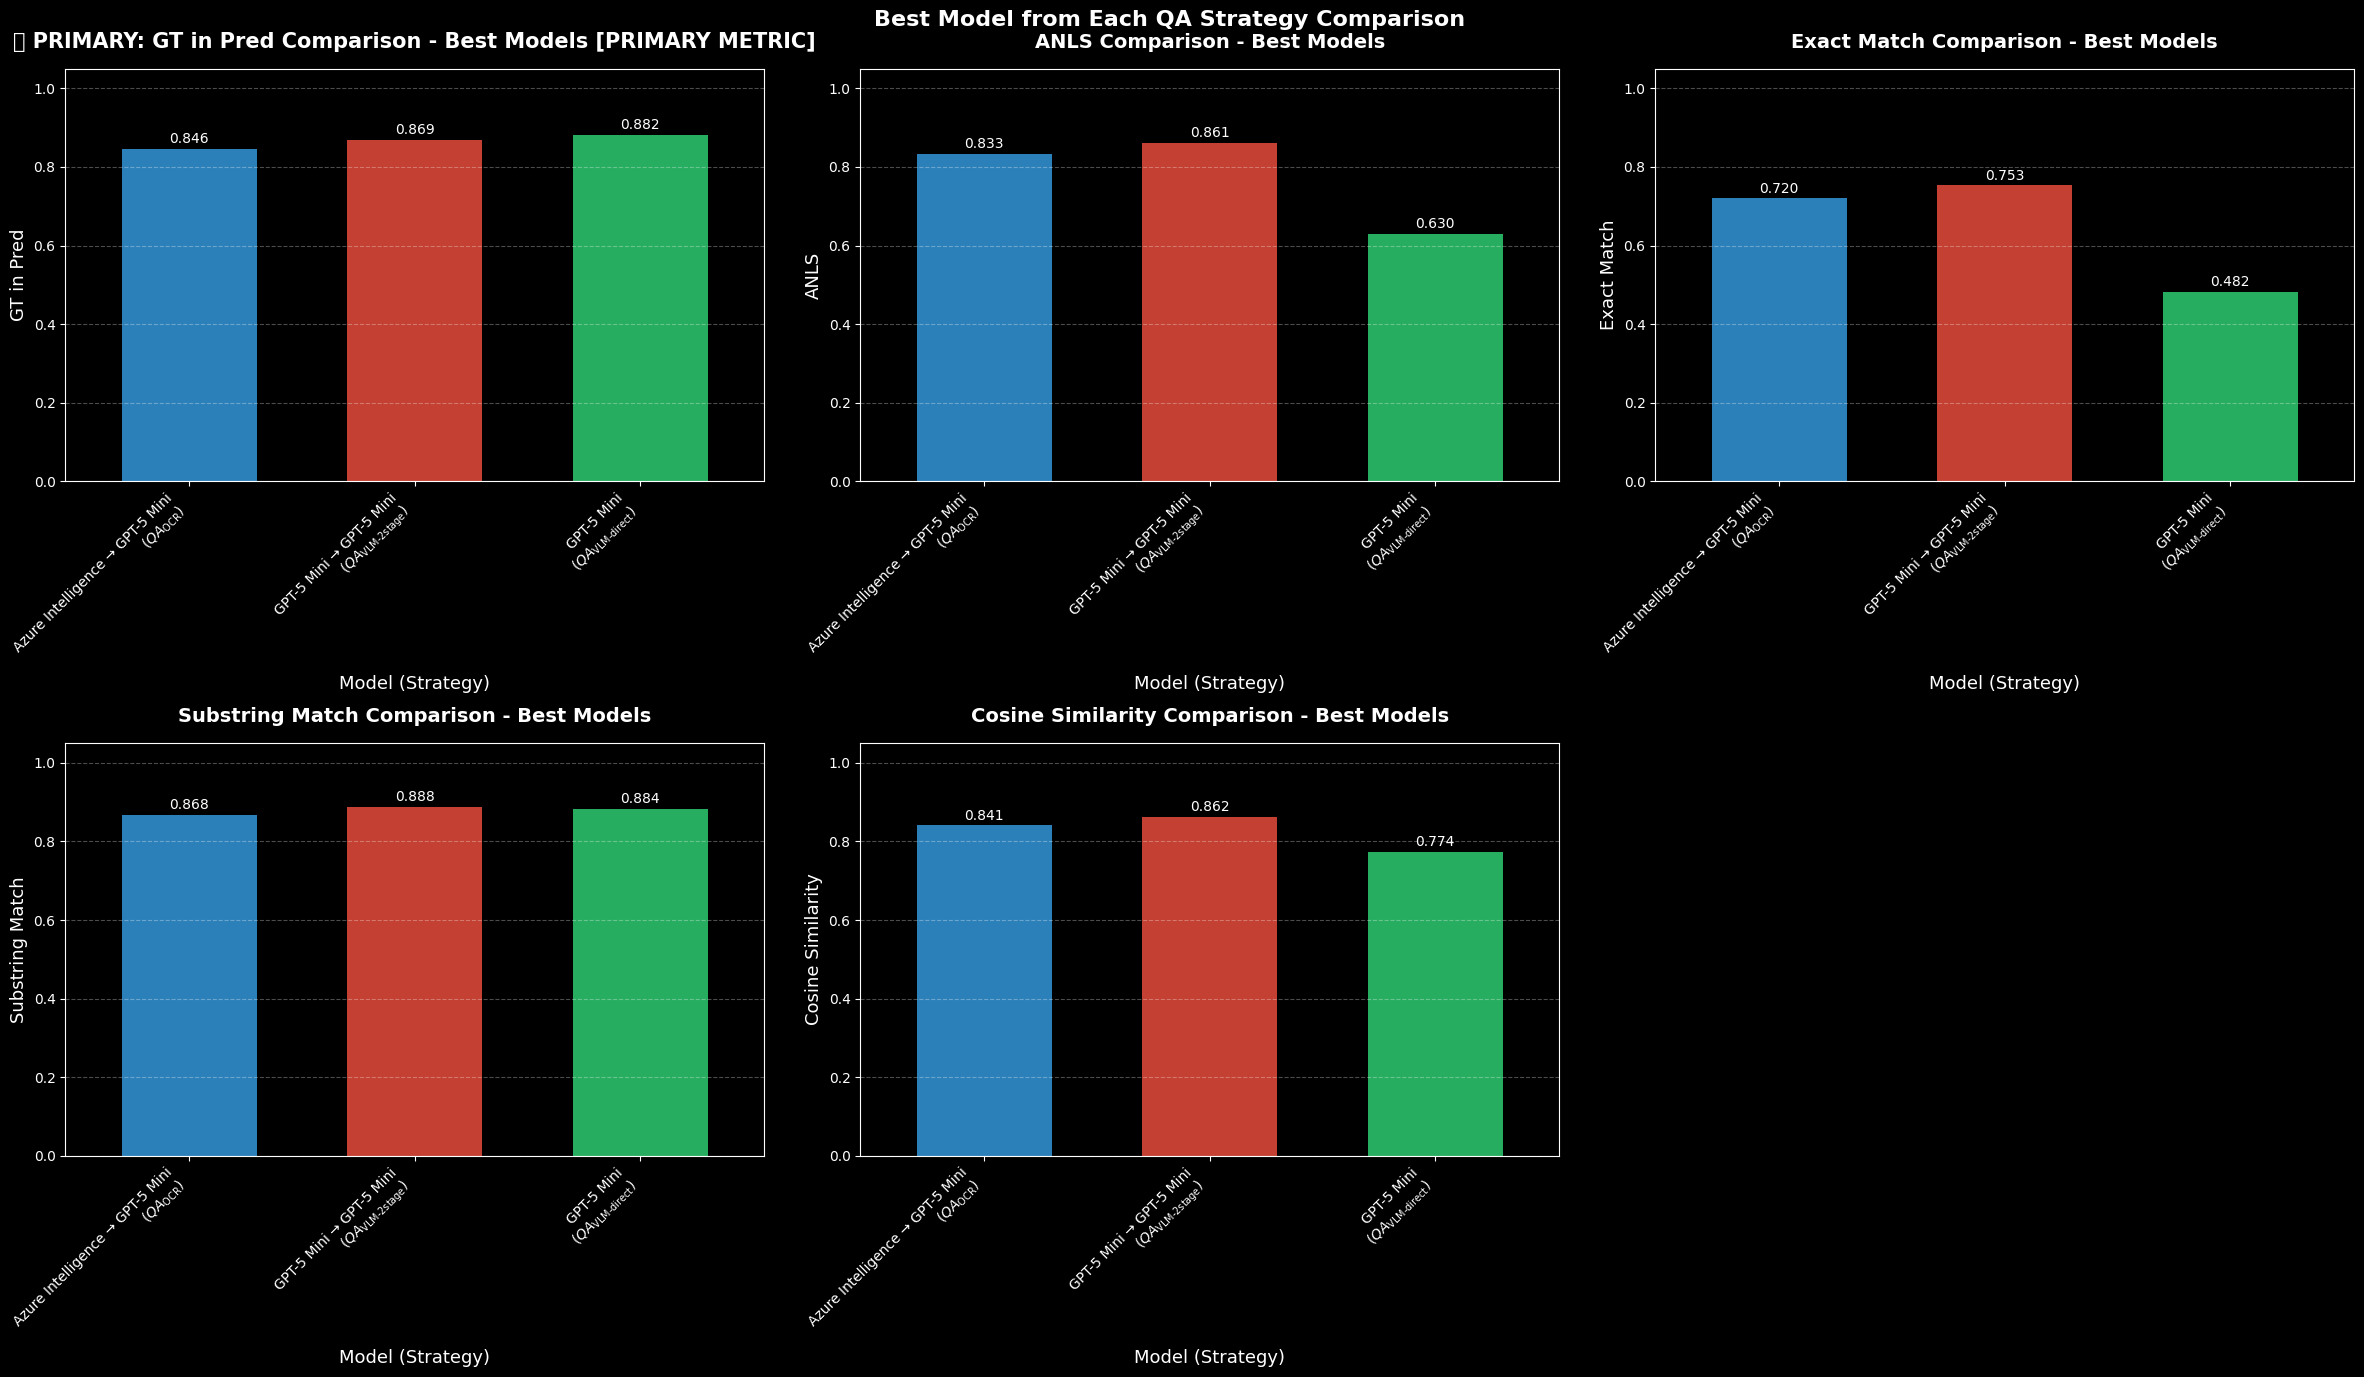


🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric
Showing best model from each strategy: QA1 (OCR+VLM), QA2 (VLM Parse+QA), QA3 (Direct VQA)


In [13]:
# Compare the best model from each QA strategy group
# Best models by GT in Pred (PRIMARY METRIC):
# - QA1: azure_intelligence__gpt-5-mini (from QA1b: GT in Pred = 0.876268)
# - QA2: gpt-5-mini__gpt-5-mini (from QA2b: GT in Pred = 0.895582) 
# - QA3: gpt-5-mini (from QA3b: GT in Pred = 0.908)

# Select the best model-phase combinations
best_models_data = summary_df.loc[
    ((summary_df['Phase'] == 'QA1b') & (summary_df['Model'] == 'azure_intelligence__gpt-5-mini')) |
    ((summary_df['Phase'] == 'QA2b') & (summary_df['Model'] == 'gpt-5-mini__gpt-5-mini')) |
    ((summary_df['Phase'] == 'QA3b') & (summary_df['Model'] == 'gpt-5-mini'))
].copy()

# Add a combined model-strategy label for display
best_models_data['Model-Strategy'] = best_models_data.apply(
    lambda row: f"{get_model_display_name(row['Model'])}\n({row['Strategy']})", axis=1
)

# Create figure for best models comparison
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

# PRIMARY METRIC FIRST, then secondary metrics
metrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    # Pivot data for grouped bar chart (models vs metrics)
    pivot_data = best_models_data.set_index('Model-Strategy')[metric]
    
    pivot_data.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_data)], alpha=0.85, width=0.6)
    
    # Emphasize primary metric
    title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
    title_suffix = " [PRIMARY METRIC]" if metric == 'GT in Pred' else ""
    
    ax.set_title(f'{title_prefix}{metric} Comparison - Best Models{title_suffix}', 
                fontsize=15 if metric == 'GT in Pred' else 14, 
                fontweight='bold', pad=15)
    ax.set_xlabel('Model (Strategy)', fontsize=13)
    ax.set_ylabel(metric, fontsize=13)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.05)
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10, padding=2)

# Hide last subplot if not needed
if len(metrics_to_plot) < 6:
    axes[-1].set_visible(False)

plt.suptitle('Best Model from Each QA Strategy Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")
print("Showing best model from each strategy: QA1 (OCR+VLM), QA2 (VLM Parse+QA), QA3 (Direct VQA)")

## 7. Visualizations - Bar Charts

Compare all metrics across models and phases.

Calculating per-sample metrics for box plots (using only valid rows)...


Phase QA1a:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0003, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0008, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0009, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0011, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0016, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0020, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0023, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0025, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0029, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0035, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0038, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini

Phase QA1b:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0001, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0003, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0006, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0008, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0009, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0011, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0013, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0015, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0016, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0019, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini_0020, model azure_intelligence__gpt-5-mini
Identical embeddings for sample docvqa_mini

...

Identical embeddings for sample docvqa_mini_0000, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0001, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0003, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0005, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0006, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0008, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0011, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0013, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0015, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0016, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0019, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0020, model gpt-5-mini__gpt-5-mini
Identical embeddings for sample docvqa_mini_0023, mo

Phase QA3a:   0%|          | 0/2 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0001, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0003, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0008, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0009, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0011, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0015, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0016, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0023, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0025, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0028, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0029, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0031, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0037, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0038, model gpt-5-nano
Identical embeddings for sample docvqa_mini_0040, model gpt-5-

Phase QA3b:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample docvqa_mini_0004, model claude_sonnet
Identical embeddings for sample docvqa_mini_0023, model claude_sonnet
Identical embeddings for sample docvqa_mini_0044, model claude_sonnet
Identical embeddings for sample docvqa_mini_0061, model claude_sonnet
Identical embeddings for sample docvqa_mini_0070, model claude_sonnet
Identical embeddings for sample docvqa_mini_0106, model claude_sonnet
Identical embeddings for sample docvqa_mini_0208, model claude_sonnet
Identical embeddings for sample docvqa_mini_0249, model claude_sonnet
Identical embeddings for sample docvqa_mini_0267, model claude_sonnet
Identical embeddings for sample docvqa_mini_0281, model claude_sonnet
Identical embeddings for sample docvqa_mini_0291, model claude_sonnet
Identical embeddings for sample docvqa_mini_0299, model claude_sonnet
Identical embeddings for sample docvqa_mini_0311, model claude_sonnet
Identical embeddings for sample docvqa_mini_0321, model claude_sonnet
Identical embeddings

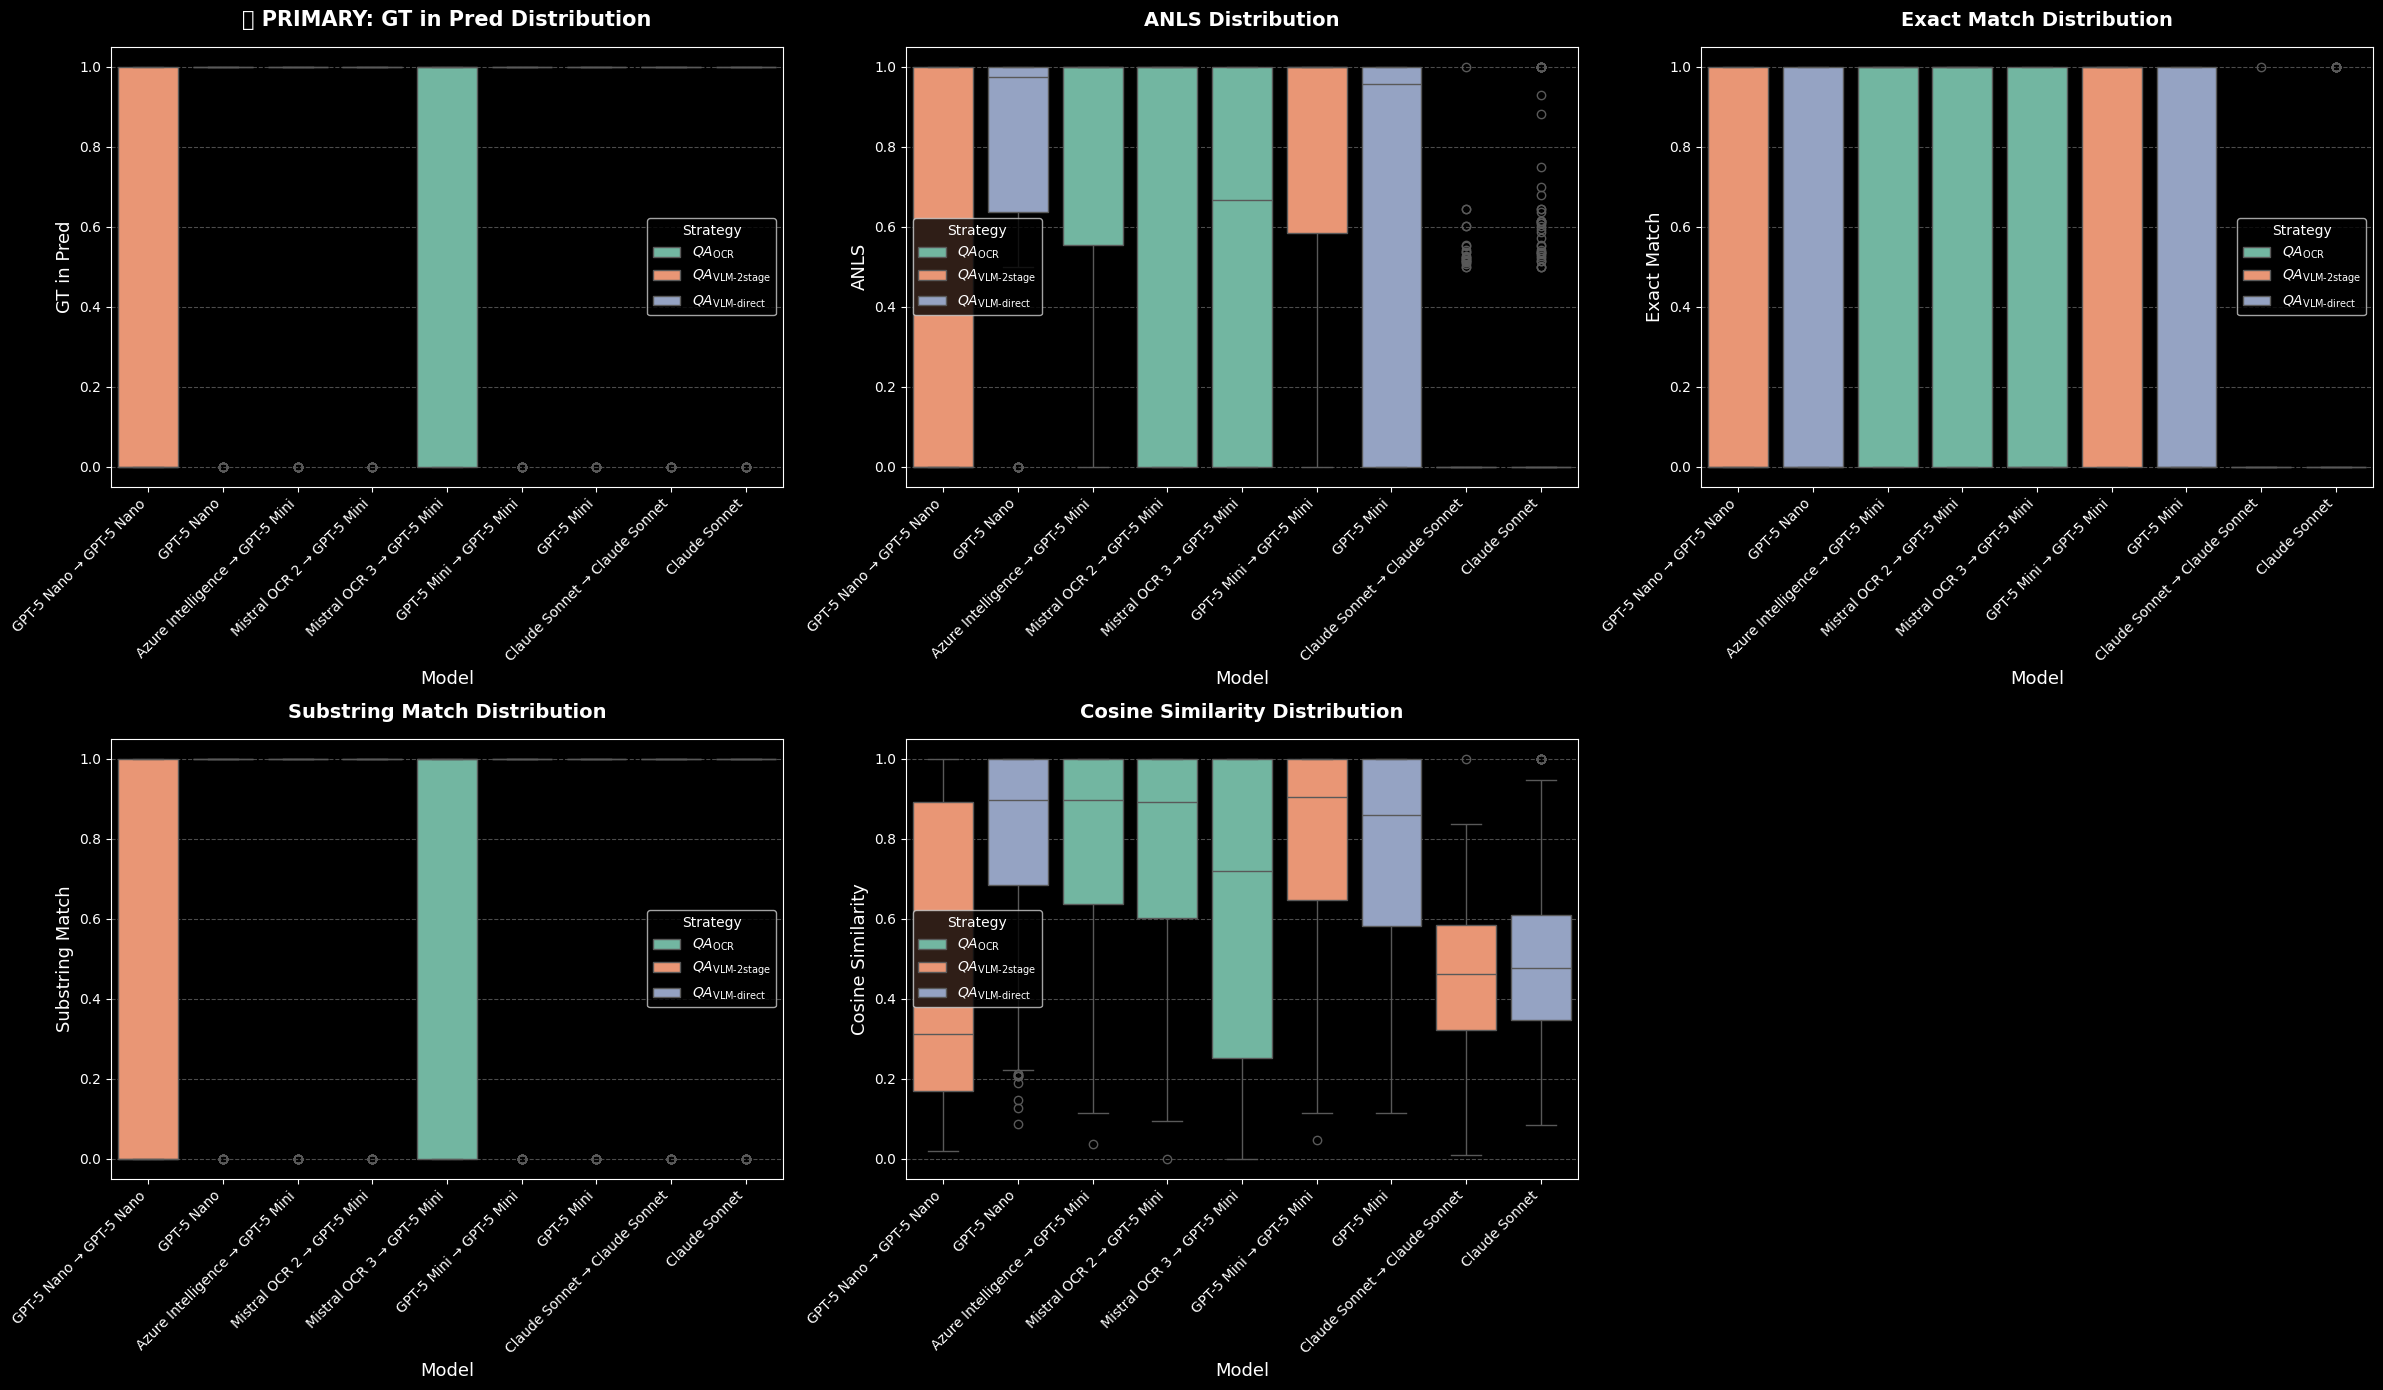


🎯 Note: Distributions show only valid samples (empty/error rows excluded)


In [14]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

print("Calculating per-sample metrics for box plots (using only valid rows)...")
for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in tqdm(pred_cols, desc=f"Phase {phase}", leave=False):
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        for _, row in df.iterrows():
            if not is_valid_row(row, pred_col, err_col):
                continue  # Skip invalid rows
            
            ground_truths = parse_ground_truths(row['ground_truths'])
            # Get extracted_text for this model (the actual parsed data from the OCR/VLM)
            extracted_text_col = f'extracted_text_{model}'
            parsed_data = row.get(extracted_text_col, None) if extracted_text_col in row.index else None
            
            metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase, 
                row['sample_id'], model, embedding_manager, parsed_data
            )
            
            sample_metrics_data.append({
                'Phase': phase,
                'Model': model,
                'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC
                'ANLS': metrics['anls'],
                'Exact Match': metrics['exact_match'],
                'Substring Match': metrics['substring_match'],
                'Cosine Similarity': metrics['cosine_similarity']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Add strategy column for grouping
sample_metrics_df['Strategy'] = sample_metrics_df['Phase'].apply(get_phase_strategy)

# Create box plots (PRIMARY METRIC FIRST)
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

metrics_for_boxplot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']

for idx, metric in enumerate(metrics_for_boxplot):
    ax = axes[idx]
    
    # Create box plot
    sample_metrics_df_sorted = sample_metrics_df.copy()
    sample_metrics_df_sorted['Model'] = pd.Categorical(
        sample_metrics_df_sorted['Model'],
        categories=sort_models(sample_metrics_df_sorted['Model'].unique().tolist()),
        ordered=True
    )
    
    sns.boxplot(data=sample_metrics_df_sorted, x='Model', y=metric, hue='Strategy', ax=ax, palette='Set2')
    
    # Emphasize primary metric
    title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
    ax.set_title(f'{title_prefix}{metric} Distribution', 
                fontsize=15 if metric == 'GT in Pred' else 14, 
                fontweight='bold', pad=15)
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel(metric, fontsize=13)
    ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(title='Strategy', loc='best')

# Hide last subplot if not needed
if len(metrics_for_boxplot) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

print("\n🎯 Note: Distributions show only valid samples (empty/error rows excluded)")

## 8. Visualizations - Box Plots

Distribution analysis showing variance and outliers.

In [15]:
    # Create heatmap data: rows = models, columns = strategies
    heatmap_data = []
    model_names = []
    strategy_names = ['$QA_{\\text{OCR}}$', '$QA_{\\text{VLM-2stage}}$', '$QA_{\\text{VLM-direct}}$']

## 9. Visualizations - Heatmaps

Model × Strategy performance heatmaps.


GT IN PRED (PRIMARY METRIC) - HEATMAPS BY STRATEGY

GT in Pred - $QA_{\text{OCR}}$

GT in Pred (PRIMARY METRIC) - $QA_{\text{OCR}}$:


,$QA_{\text{OCR}}^{\text{simple}}$,$QA_{\text{OCR}}^{\text{generic}}$,$QA_{\text{OCR}}^{\text{task-aware}}$
Mistral OCR 3 → GPT-5 Mini,0.574037,0.555332,0.579268
Mistral OCR 2 → GPT-5 Mini,0.784990,0.804829,0.793939
Azure Intelligence → GPT-5 Mini,0.813906,0.845842,0.830612


/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
Font 'default' does not have a glyph for '\U0001f3af' [U+1f3af], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f3af' [U+1f3af], substituting with a dummy symbol.
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


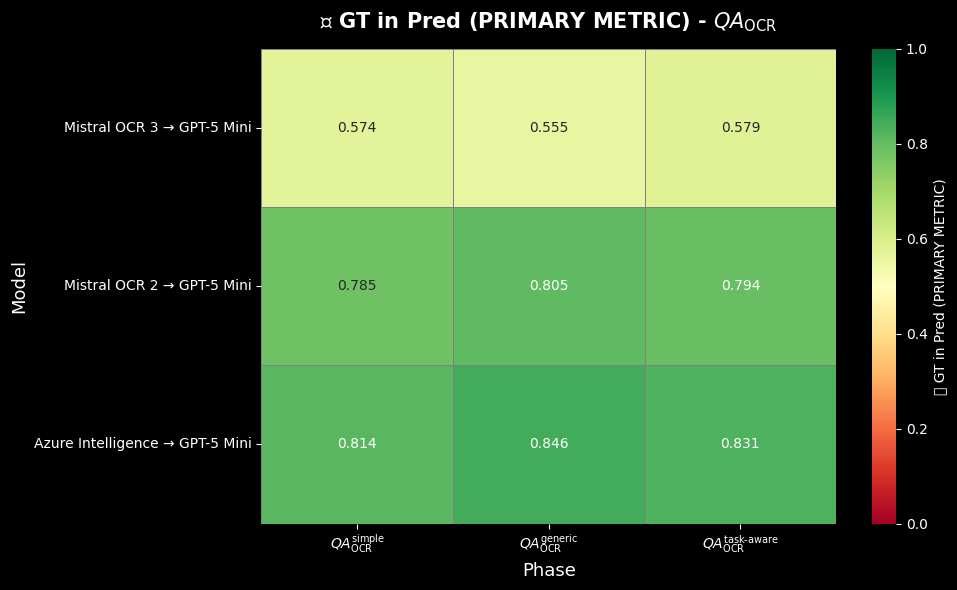


GT in Pred - $QA_{\text{VLM-2stage}}$

GT in Pred (PRIMARY METRIC) - $QA_{\text{VLM-2stage}}$:


,$QA_{\text{VLM-2stage}}^{\text{cot}}$,$QA_{\text{VLM-2stage}}^{\text{generic+cot}}$
GPT-5 Nano → GPT-5 Nano,0.435583,0.398773
GPT-5 Mini → GPT-5 Mini,0.823293,0.869478
Claude Sonnet → Claude Sonnet,0.849699,0.849398


/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
Font 'default' does not have a glyph for '\U0001f3af' [U+1f3af], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f3af' [U+1f3af], substituting with a dummy symbol.
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


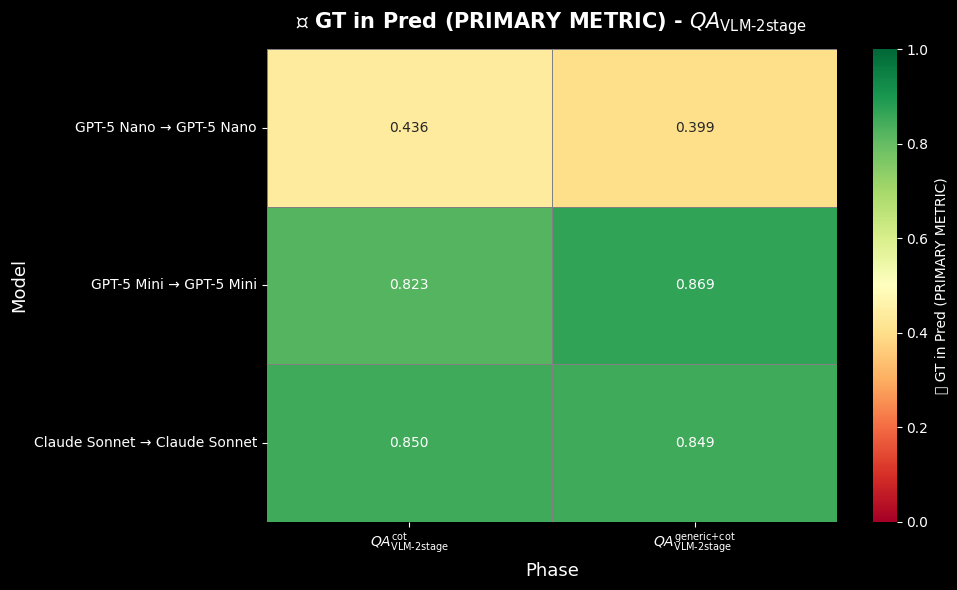


GT in Pred - $QA_{\text{VLM-direct}}$

GT in Pred (PRIMARY METRIC) - $QA_{\text{VLM-direct}}$:


,$QA_{\text{VLM-direct}}^{\text{sonnet}}$,$QA_{\text{VLM-direct}}^{\text{multi}}$
GPT-5 Nano,0.846,0.853707
GPT-5 Mini,NaN,0.882000
Claude Sonnet,0.876,0.878000


/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
Font 'default' does not have a glyph for '\U0001f3af' [U+1f3af], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f3af' [U+1f3af], substituting with a dummy symbol.
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


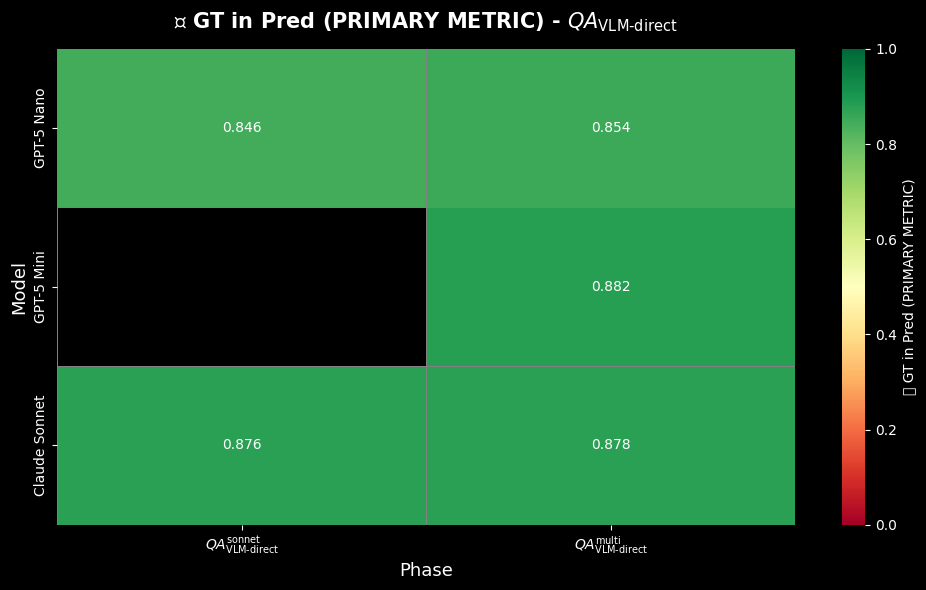


🎯 Note: GT in Pred (Ground Truth in Prediction) is the PRIMARY metric
Higher values (green) indicate better performance


In [28]:
# Heatmap of GT in Pred for each strategy group
print("\n" + "="*120)
print("GT IN PRED (PRIMARY METRIC) - HEATMAPS BY STRATEGY")
print("="*120)

for strategy_name, phases in phase_groups.items():
    print(f"\n{'='*80}")
    print(f"GT in Pred - {strategy_name}")
    print(f"{'='*80}")
    
    # Filter phases for this strategy that exist in our data
    strategy_phase_names = [p for p in phases if p in metrics_results]
    if not strategy_phase_names:
        print(f"⚠️ No phases found for {strategy_name}")
        continue
    
    # Get all unique models across the phases in this strategy
    all_models = set()
    for phase in strategy_phase_names:
        if phase in metrics_results:
            all_models.update(metrics_results[phase].keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data: rows = models, columns = phases
    heatmap_data = []
    for model in all_models:
        row_data = []
        for phase in strategy_phase_names:
            if phase in metrics_results and model in metrics_results[phase]:
                value = metrics_results[phase][model].get('gt_in_pred', np.nan)
                row_data.append(value)
            else:
                row_data.append(np.nan)
        heatmap_data.append(row_data)
    
    # Create DataFrame for heatmap
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in all_models],
        columns=[get_phase_formal_name(p) for p in strategy_phase_names]
    )
    
    # Print the table
    print(f"\nGT in Pred (PRIMARY METRIC) - {strategy_name}:")
    display(heatmap_df)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(max(10, len(strategy_phase_names) * 3), max(6, len(all_models) * 0.6)))
    
    # Use colormap: green for high values (good), red for low values (bad)
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='RdYlGn', 
                ax=ax, cbar_kws={'label': '🎯 GT in Pred (PRIMARY METRIC)'}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
    
    ax.set_title(f'🎯 GT in Pred (PRIMARY METRIC) - {strategy_name}', 
                fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Phase', fontsize=13)
    ax.set_ylabel('Model', fontsize=13)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*120)
print("🎯 Note: GT in Pred (Ground Truth in Prediction) is the PRIMARY metric")
print("Higher values (green) indicate better performance")
print("="*120)

/var/folders/g9/llcmfs150lg102rht49jlz980000gq/T/ipykernel_43206/2612127445.py:43: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


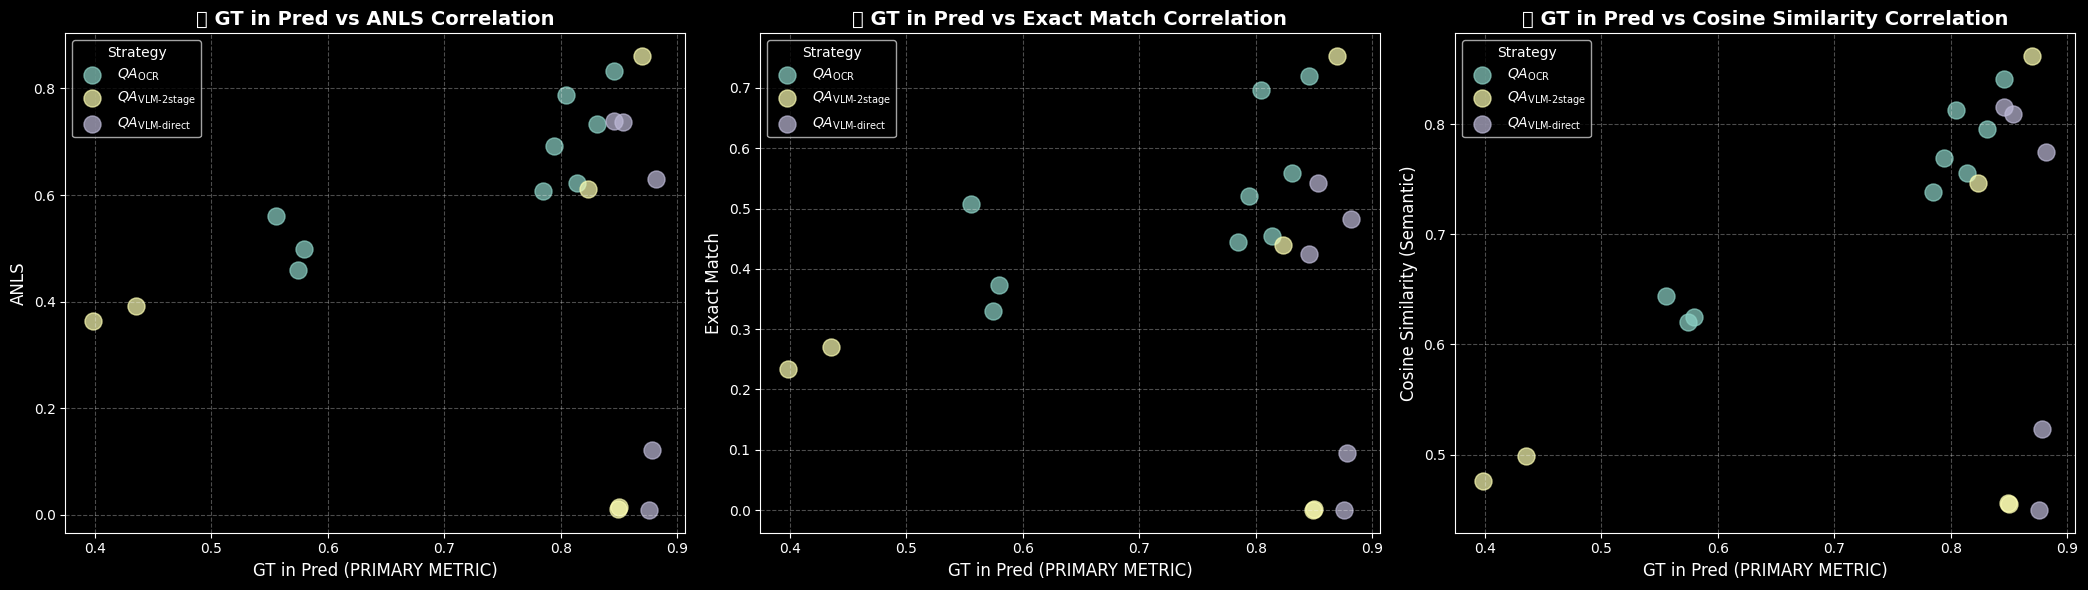


🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)


In [16]:
# Scatter plots: GT in Pred (PRIMARY) vs other metrics
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# GT in Pred vs ANLS
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['GT in Pred'], strategy_data['ANLS'], 
               s=150, alpha=0.7, label=strategy)

ax1.set_title('🎯 GT in Pred vs ANLS Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax1.set_ylabel('ANLS', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Exact Match
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['GT in Pred'], strategy_data['Exact Match'], 
               s=150, alpha=0.7, label=strategy)

ax2.set_title('🎯 GT in Pred vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax2.set_ylabel('Exact Match', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Cosine Similarity
ax3 = axes[2]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax3.scatter(strategy_data['GT in Pred'], strategy_data['Cosine Similarity'], 
               s=150, alpha=0.7, label=strategy)

ax3.set_title('🎯 GT in Pred vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax3.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax3.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax3.legend(title='Strategy', loc='best')
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)")

## 10. Visualizations - Scatter Plots

Correlation analysis between metrics.

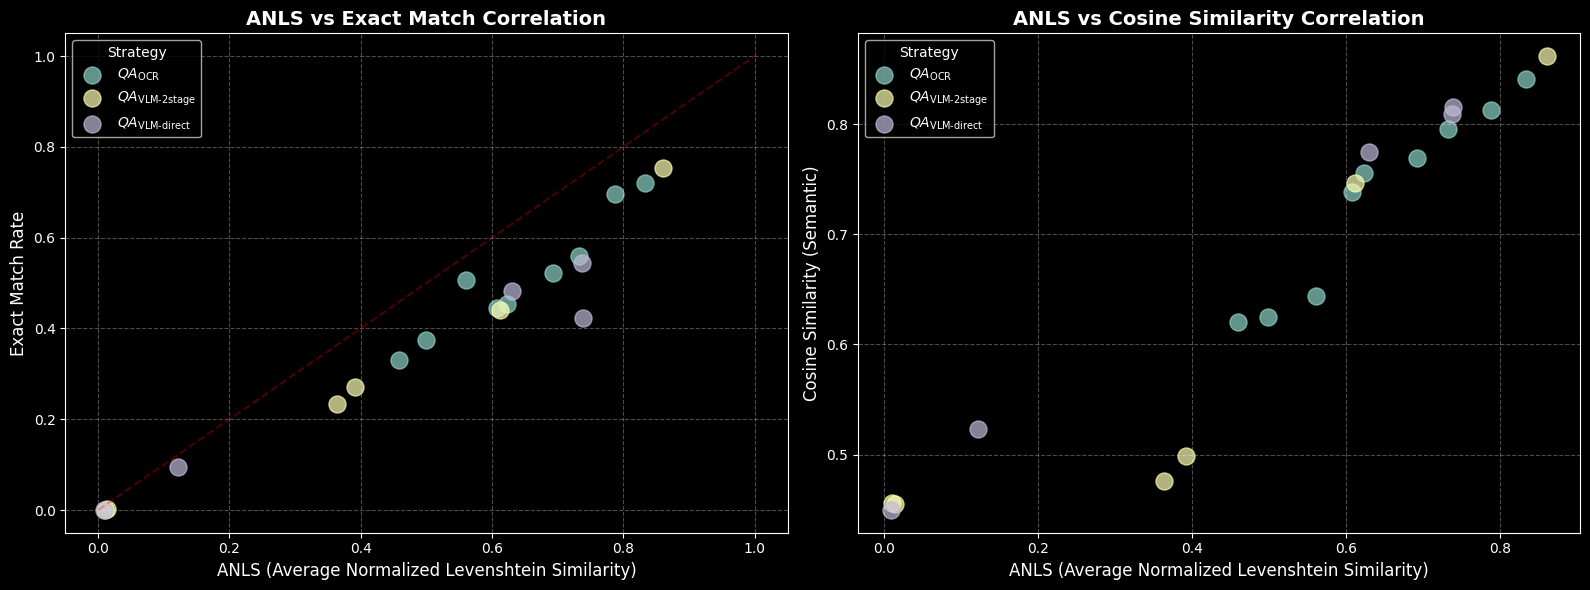

In [17]:
# Scatter plots: ANLS vs other metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANLS vs Exact Match
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['ANLS'], strategy_data['Exact Match'], 
               s=150, alpha=0.7, label=strategy)

ax1.set_title('ANLS vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax1.set_ylabel('Exact Match Rate', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')
ax1.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='ANLS=EM')

# ANLS vs Cosine Similarity
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['ANLS'], strategy_data['Cosine Similarity'], 
               s=150, alpha=0.7, label=strategy)

ax2.set_title('ANLS vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax2.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 11. QA-Specific Analysis

Analyze question types, answer lengths, and QA-specific patterns.


Question Type Distribution (QA1a):
  What           :  322 questions ( 64.4%)
  Who            :   40 questions (  8.0%)
  Other          :   39 questions (  7.8%)
  How many/much  :   39 questions (  7.8%)
  Which          :   33 questions (  6.6%)
  When           :    8 questions (  1.6%)
  Where          :    8 questions (  1.6%)
  Yes/No         :    6 questions (  1.2%)
  How            :    5 questions (  1.0%)


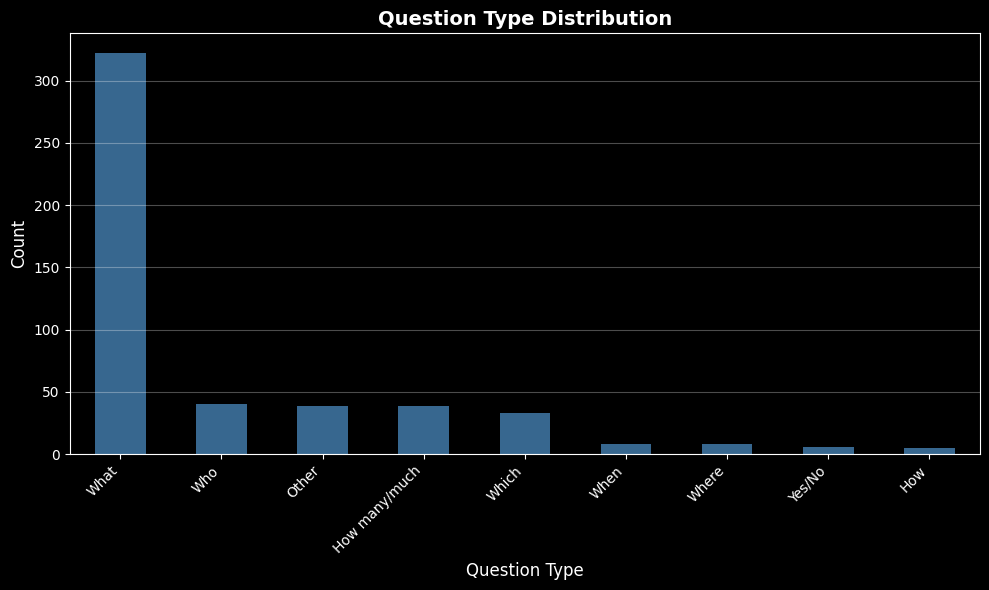

In [18]:
# Question type analysis
if len(phase_dfs) > 0:
    # Use first available phase for analysis
    analysis_phase = list(phase_dfs.keys())[0]
    df_analysis = phase_dfs[analysis_phase].copy()
    
    # Add question type categorization
    df_analysis['question_type'] = df_analysis['question'].apply(categorize_question_type)
    
    print(f"\nQuestion Type Distribution ({analysis_phase}):")
    print("=" * 80)
    type_counts = df_analysis['question_type'].value_counts()
    for qtype, count in type_counts.items():
        pct = count / len(df_analysis) * 100
        print(f"  {qtype:15s}: {count:4d} questions ({pct:5.1f}%)")
    
    # Visualize question types
    fig, ax = plt.subplots(figsize=(10, 6))
    type_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title('Question Type Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Type', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

/var/folders/g9/llcmfs150lg102rht49jlz980000gq/T/ipykernel_43206/3520156420.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=anls_length_df, x='question_length_bin', y='anls', ax=ax, palette='viridis')


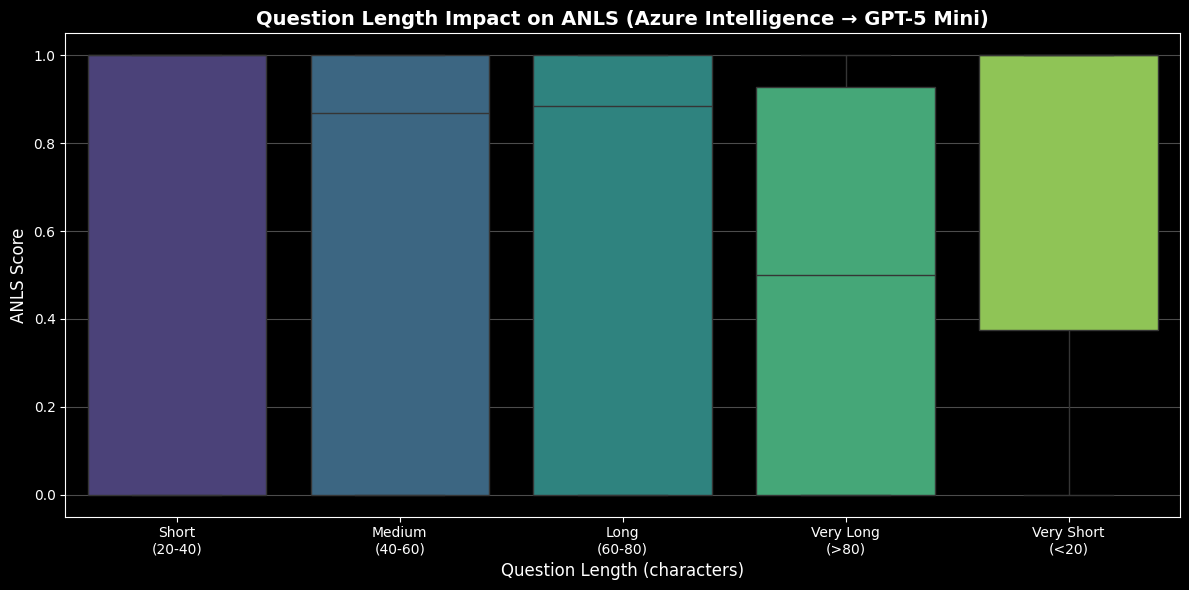

In [19]:
# Question length impact on performance
if len(phase_dfs) > 0:
    df_analysis['question_length'] = df_analysis['question'].astype(str).str.len()
    df_analysis['question_length_bin'] = pd.cut(
        df_analysis['question_length'],
        bins=[0, 20, 40, 60, 80, 1000],
        labels=['Very Short\n(<20)', 'Short\n(20-40)', 'Medium\n(40-60)', 'Long\n(60-80)', 'Very Long\n(>80)']
    )
    
    # Calculate ANLS for first model per length bin
    pred_col = [col for col in df_analysis.columns if col.startswith('prediction_')][0]
    model_name = pred_col.replace('prediction_', '')
    
    anls_by_length = []
    for _, row in df_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[pred_col]), ground_truths, threshold=0.5)
        anls_by_length.append({
            'question_length_bin': row['question_length_bin'],
            'anls': anls
        })
    
    anls_length_df = pd.DataFrame(anls_by_length)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=anls_length_df, x='question_length_bin', y='anls', ax=ax, palette='viridis')
    ax.set_title(f'Question Length Impact on ANLS ({get_model_display_name(model_name)})', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Length (characters)', fontsize=12)
    ax.set_ylabel('ANLS Score', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [20]:
    ax.set_title('🎯 QA Strategy Comparison (GT in Pred = PRIMARY METRIC)', fontsize=15, fontweight='bold')

Text(0.5, 1.0, '🎯 QA Strategy Comparison (GT in Pred = PRIMARY METRIC)')

## 12. Phase Comparison Analysis

Compare the three QA strategies: OCR+VLM, VLM Parse+QA, and Direct VQA.

In [21]:
print("\nQA Strategy Comparison:")
print("=" * 100)


QA Strategy Comparison:


## 13. Sample-Level Error Analysis

Identify easiest and hardest questions to understand error patterns.

In [22]:
# Analyze best and worst performing samples
if len(phase_dfs) > 0:
    analysis_phase = list(phase_dfs.keys())[0]
    df_error_analysis = phase_dfs[analysis_phase].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_error_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate ANLS for each sample
    anls_scores = []
    for _, row in df_error_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[f'prediction_{first_model}']), ground_truths, threshold=0.5)
        anls_scores.append(anls)
    
    df_error_analysis['anls'] = anls_scores
    
    # Get best and worst samples
    best_samples = df_error_analysis.nlargest(10, 'anls')
    worst_samples = df_error_analysis.nsmallest(10, 'anls')
    
    print("\n" + "="*120)
    print(f"EASIEST QUESTIONS (Highest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")
    
    print("\n" + "="*120)
    print(f"HARDEST QUESTIONS (Lowest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")


EASIEST QUESTIONS (Highest ANLS) - Model: Azure Intelligence → GPT-5 Mini

Sample: docvqa_mini_0003 | ANLS: 1.0000
Question: What is the word in double quote?
Ground Truths: "matching", "Matching"
Prediction: matching

Sample: docvqa_mini_0008 | ANLS: 1.0000
Question: What is Project Name ?
Ground Truths: "Seattle Region Name Generation Card"
Prediction: Seattle Region Name Generation Card

Sample: docvqa_mini_0009 | ANLS: 1.0000
Question: What is the Program # ?
Ground Truths: "701998"
Prediction: 701998

Sample: docvqa_mini_0010 | ANLS: 1.0000
Question: What is the page number?
Ground Truths: "- 5 -", "5"
Prediction: 5

Sample: docvqa_mini_0011 | ANLS: 1.0000
Question: Who is the Chief Executive Officer ( see the bottom part of the letter)?
Ground Truths: "Howard C. Harder"
Prediction: Howard C. Harder

Sample: docvqa_mini_0016 | ANLS: 1.0000
Question: How many ‘total implanted’?
Ground Truths: "1100"
Prediction: 1100

Sample: docvqa_mini_0018 | ANLS: 1.0000
Question: how much is th

## 14. Inference Time Analysis

Analyze speed vs accuracy trade-offs across strategies.


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms),Strategy
1,QA1a,mistral_document_ai__gpt-5-mini,5737.765616,5121.022582,$QA_{\text{OCR}}$
2,QA1a,mistral_ocr_3__gpt-5-mini,6724.538782,5720.410943,$QA_{\text{OCR}}$
0,QA1a,azure_intelligence__gpt-5-mini,6871.804197,5698.948145,$QA_{\text{OCR}}$
5,QA1b,mistral_ocr_3__gpt-5-mini,5596.943581,5220.072627,$QA_{\text{OCR}}$
4,QA1b,mistral_document_ai__gpt-5-mini,5608.246081,5091.107368,$QA_{\text{OCR}}$
3,QA1b,azure_intelligence__gpt-5-mini,6485.472407,5464.203477,$QA_{\text{OCR}}$
7,QA1c,mistral_document_ai__gpt-5-mini,7295.687834,6807.071447,$QA_{\text{OCR}}$
6,QA1c,azure_intelligence__gpt-5-mini,7884.633410,6996.329904,$QA_{\text{OCR}}$
8,QA1c,mistral_ocr_3__gpt-5-mini,8033.074317,7454.959869,$QA_{\text{OCR}}$
10,QA2a,gpt-5-mini__gpt-5-mini,18140.170071,16755.878568,$QA_{\text{VLM-2stage}}$


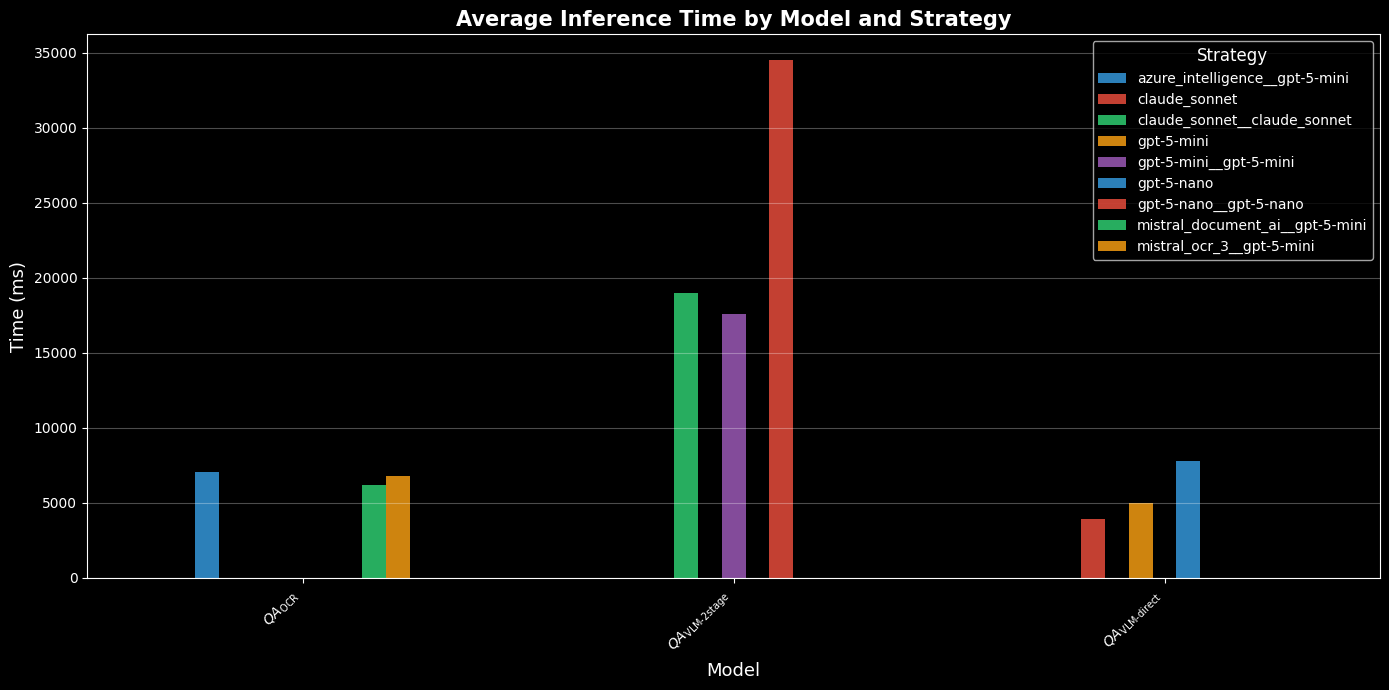

/var/folders/g9/llcmfs150lg102rht49jlz980000gq/T/ipykernel_43206/1263043208.py:70: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


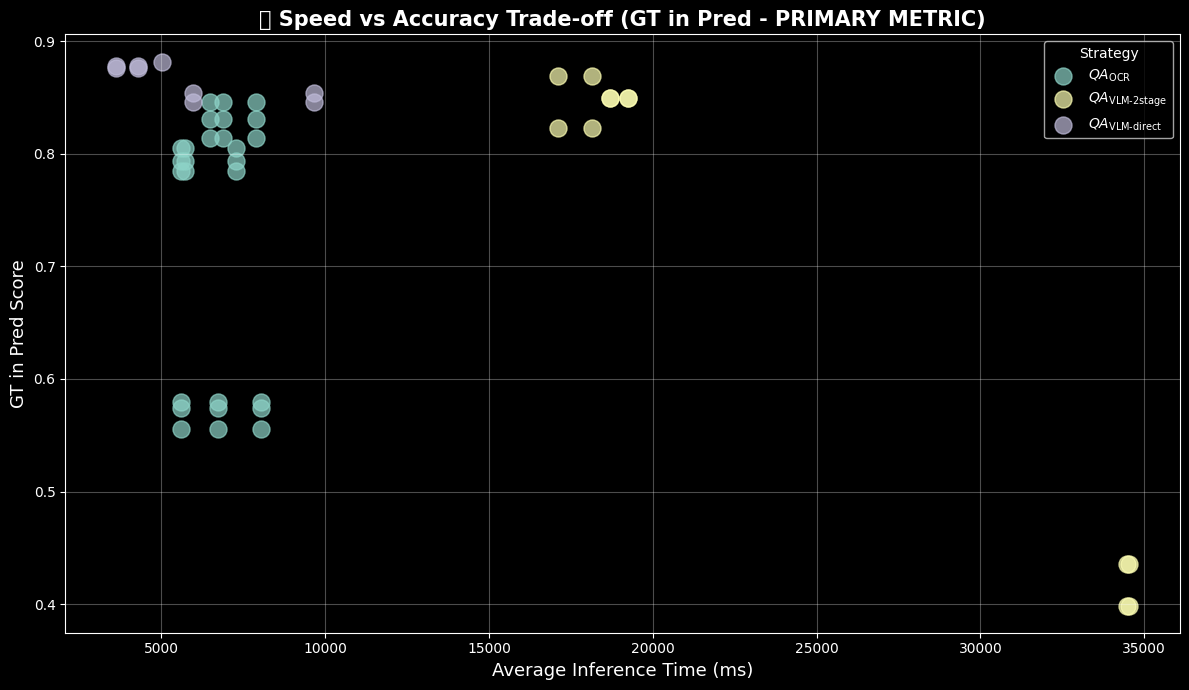

In [23]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    # Add strategy column
    inference_df['Strategy'] = inference_df['Phase'].apply(get_phase_strategy)
    
    print("\nInference Time Summary:")
    print("="*120)
    display(inference_df.sort_values(['Phase', 'Mean Time (ms)']))
    
    # Visualization - aggregate by strategy
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Aggregate by strategy
    strategy_time = inference_df.groupby(['Strategy', 'Model'])['Mean Time (ms)'].mean().unstack()
    strategy_time = strategy_time.reindex(sort_models(strategy_time.index.tolist()))
    strategy_time.plot(kind='bar', ax=ax, color=colors_palette[:len(strategy_time.columns)], alpha=0.85)
    
    ax.set_title('Average Inference Time by Model and Strategy', fontsize=15, fontweight='bold')
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel('Time (ms)', fontsize=13)
    ax.legend(title='Strategy', title_fontsize=12, fontsize=10, loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], 
                       rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Speed vs Accuracy scatter plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Merge inference time with GT in Pred scores (PRIMARY METRIC)
    speed_accuracy = pd.merge(
        inference_df[['Strategy', 'Model', 'Mean Time (ms)']],
        summary_df[['Strategy', 'Model', 'GT in Pred']],
        on=['Strategy', 'Model']
    )
    
    for strategy in speed_accuracy['Strategy'].unique():
        strategy_data = speed_accuracy[speed_accuracy['Strategy'] == strategy]
        ax.scatter(strategy_data['Mean Time (ms)'], strategy_data['GT in Pred'], 
                  s=150, alpha=0.7, label=strategy)
    
    ax.set_title('🎯 Speed vs Accuracy Trade-off (GT in Pred - PRIMARY METRIC)', fontsize=15, fontweight='bold')
    ax.set_xlabel('Average Inference Time (ms)', fontsize=13)
    ax.set_ylabel('GT in Pred Score', fontsize=13)
    ax.legend(title='Strategy', loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 10.5 Ground Truth in Parsed Data Analysis

Comprehensive analysis of parsing effectiveness through GT in Parsed Data metric, including heatmaps and regression analysis.



GROUND TRUTH IN PARSED DATA - Comprehensive Analysis

This metric measures whether ground truth answers appear in parsed/extracted text.
High values indicate strong parsing effectiveness. We analyze this vs QA performance metrics.


--- Part 1: Heatmap Visualizations ---


Ground Truth in Parsed Data - $QA_{\text{OCR}}$

Ground Truth in Parsed Data - $QA_{\text{OCR}}$:


,QA1a,QA1b,QA1c
Mistral OCR 3 → GPT-5 Mini,0.614604,0.601610,0.609756
Mistral OCR 2 → GPT-5 Mini,0.847870,0.845070,0.840404
Azure Intelligence → GPT-5 Mini,0.871166,0.870183,0.869388


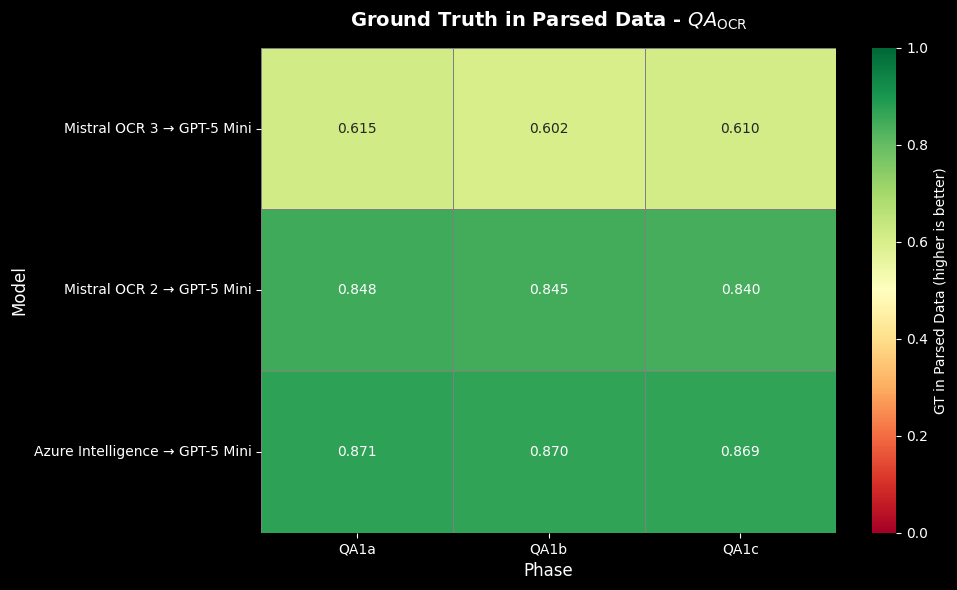


Ground Truth in Parsed Data - $QA_{\text{VLM-2stage}}$

Ground Truth in Parsed Data - $QA_{\text{VLM-2stage}}$:


,QA2a,QA2b
GPT-5 Nano → GPT-5 Nano,0.447853,0.415133
GPT-5 Mini → GPT-5 Mini,0.869478,0.873494
Claude Sonnet → Claude Sonnet,0.867735,0.883534


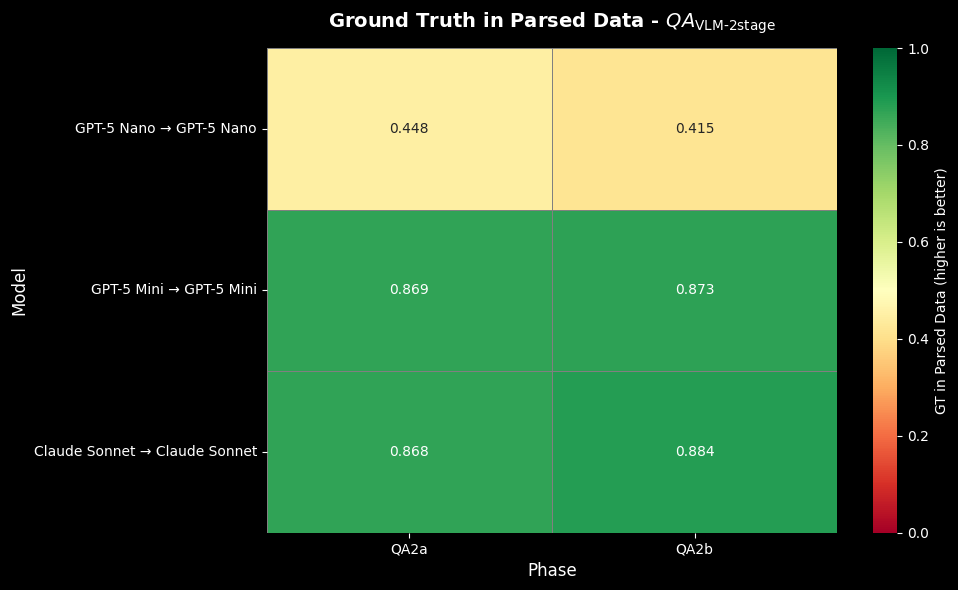


Ground Truth in Parsed Data - $QA_{\text{VLM-direct}}$

Ground Truth in Parsed Data - $QA_{\text{VLM-direct}}$:


,QA3a,QA3b
GPT-5 Nano,0.0,0.0
GPT-5 Mini,NaN,0.0
Claude Sonnet,0.0,0.0


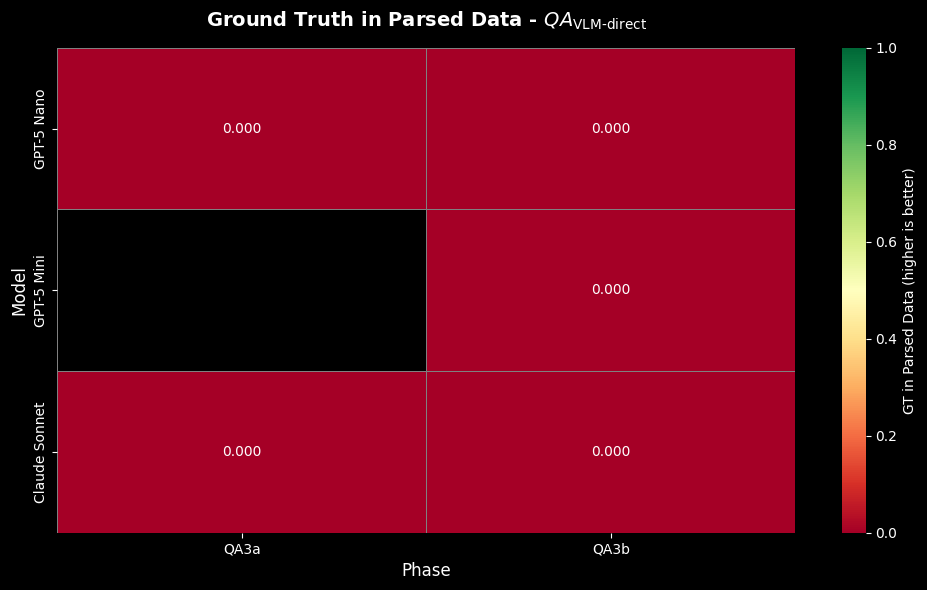



--- Part 2: Regression Analysis ---

$QA_{\text{OCR}}$:
  Regression: y = 0.9794x + -0.0271
  R² = 0.9909, Pearson r = 0.9954, p-value = 0.000000
$QA_{\text{VLM-2stage}}$:
  Regression: y = 0.9746x + -0.0034
  R² = 0.9959, Pearson r = 0.9979, p-value = 0.000006
$QA_{\text{VLM-direct}}$: ⚠️ Insufficient data variance for regression (n=5, std_x=0.0000)


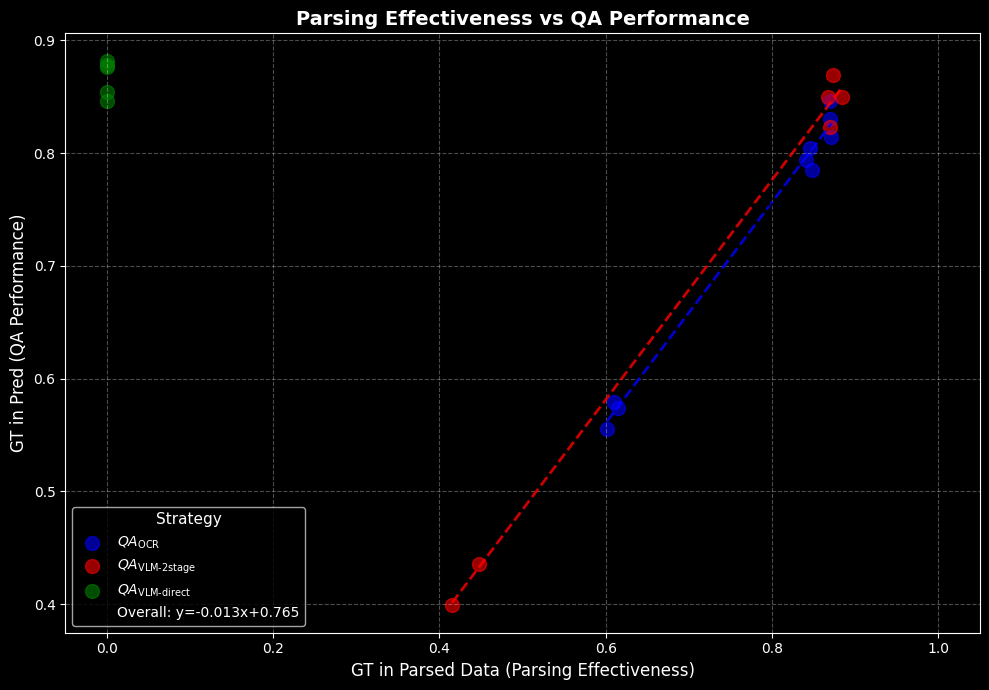

$QA_{\text{OCR}}$:
  ANLS Regression: y = 0.8250x + 0.0049
  R² = 0.6509, Pearson r = 0.8068, p-value = 0.008593
$QA_{\text{VLM-2stage}}$:
  ANLS Regression: y = -0.0148x + 0.3861
  R² = 0.0001, Pearson r = -0.0102, p-value = 0.984760
$QA_{\text{VLM-direct}}$: ⚠️ Insufficient data variance for ANLS regression


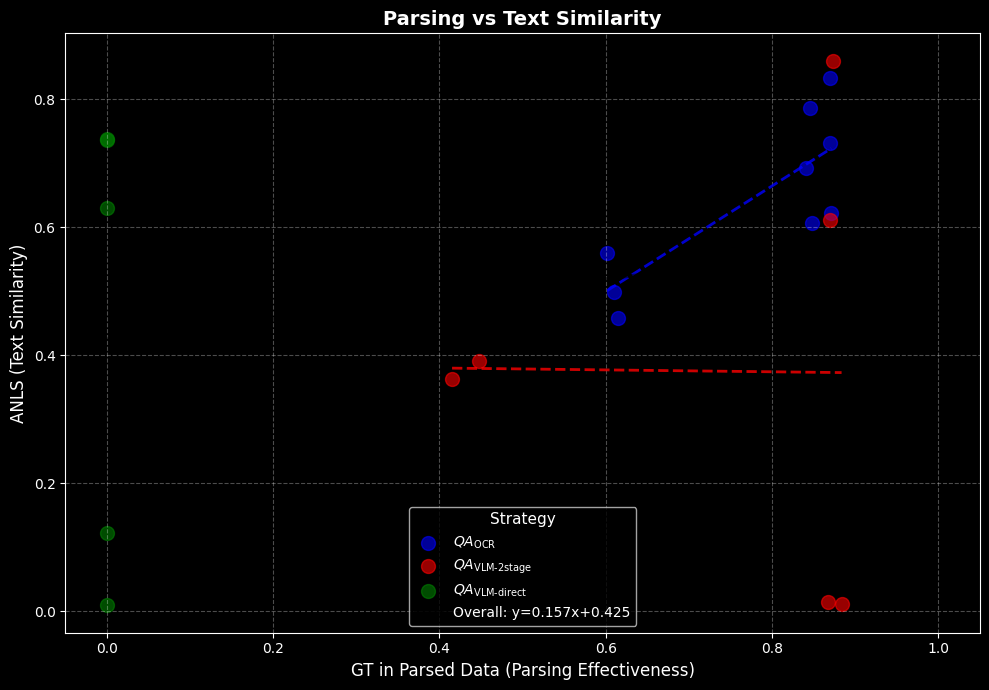


INTERPRETATION GUIDE

• High R² values (>0.5) indicate strong linear relationship between parsing and QA performance
• Positive slopes suggest: better parsing → better QA results
• Steep slopes mean parsing improvements significantly boost QA performance
• Low p-values (<0.05) indicate statistically significant relationships
• Comparison helps identify: Is parsing or LLM QA the bottleneck?
• ⚠️ If regression fails, it may indicate all GT in Parsed Data values are 0 or identical



In [24]:
from scipy import stats

print("\n" + "="*120)
print("GROUND TRUTH IN PARSED DATA - Comprehensive Analysis")
print("="*120)
print("\nThis metric measures whether ground truth answers appear in parsed/extracted text.")
print("High values indicate strong parsing effectiveness. We analyze this vs QA performance metrics.\n")

# Auto-detect strategy groups from available phases
has_qa4 = any('QA4' in phase for phase in metrics_results.keys())

strategy_groups = {
    '$QA_{\\text{OCR}}$': ['QA1a', 'QA1b', 'QA1c'],
    '$QA_{\\text{VLM-2stage}}$': ['QA2a', 'QA2b', 'QA2c'],
    '$QA_{\\text{VLM-direct}}$': ['QA3a', 'QA3b']
}

if has_qa4:
    strategy_groups['$QA_{\\text{special}}$'] = ['QA4a', 'QA4b', 'QA4c']

# Color mapping for strategies
strategy_colors = {
    '$QA_{\\text{OCR}}$': 'blue',
    '$QA_{\\text{VLM-2stage}}$': 'red',
    '$QA_{\\text{VLM-direct}}$': 'green',
    '$QA_{\\text{special}}$': 'orange'
}

def can_fit_regression(x_vals, y_vals, min_points=3):
    """Check if we can safely perform linear regression."""
    if len(x_vals) < min_points or len(y_vals) < min_points:
        return False
    # Check for variance in x values (can't fit if all x are the same)
    if np.std(x_vals) < 1e-10:
        return False
    # Check for any NaN or infinite values
    if any(np.isnan(x_vals)) or any(np.isnan(y_vals)):
        return False
    if any(np.isinf(x_vals)) or any(np.isinf(y_vals)):
        return False
    return True

# ============================================================================
# Part 1: Heatmap Visualizations
# ============================================================================
print("\n--- Part 1: Heatmap Visualizations ---\n")

for strategy_name, phases in strategy_groups.items():
    print(f"\n{'='*80}")
    print(f"Ground Truth in Parsed Data - {strategy_name}")
    print(f"{'='*80}")
    
    # Filter phases for this strategy
    strategy_phase_names = [p for p in phases if p in metrics_results]
    if not strategy_phase_names:
        print(f"⚠️ No phases found for {strategy_name}")
        continue
    
    # Create heatmap data: rows = models, columns = phases in this strategy
    heatmap_data = []
    model_names = []
    
    # Get all unique models across the phases in this strategy
    all_models = set()
    for phase in strategy_phase_names:
        if phase in metrics_results:
            all_models.update(metrics_results[phase].keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in strategy_phase_names:
            if phase in metrics_results and model in metrics_results[phase]:
                value = metrics_results[phase][model].get('gt_in_parsed', np.nan)
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in model_names],
        columns=strategy_phase_names
    )
    
    # Print the table
    print(f"\nGround Truth in Parsed Data - {strategy_name}:")
    display(heatmap_df)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Use colormap: green for good, red for bad
    cmap = 'RdYlGn'
    cbar_label = 'GT in Parsed Data (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
    
    ax.set_title(f'Ground Truth in Parsed Data - {strategy_name}', 
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# Part 2: Regression Analysis - GT in Parsed Data vs GT in Pred
# ============================================================================
print("\n\n--- Part 2: Regression Analysis ---\n")

# Scatter plot 1: GT in Parsed Data vs GT in Pred
fig1, ax1 = plt.subplots(figsize=(10, 7))
x_vals_all = []
y_vals_all = []

for strategy_name in strategy_groups.keys():
    x_vals = []
    y_vals = []
    
    for phase in strategy_groups[strategy_name]:
        if phase in metrics_results:
            for model in metrics_results[phase]:
                gt_parsed = metrics_results[phase][model].get('gt_in_parsed', np.nan)
                gt_pred = metrics_results[phase][model].get('gt_in_pred', np.nan)
                
                if not np.isnan(gt_parsed) and not np.isnan(gt_pred):
                    x_vals.append(gt_parsed)
                    y_vals.append(gt_pred)
    
    if x_vals:
        x_vals_all.extend(x_vals)
        y_vals_all.extend(y_vals)
        
        # Plot points
        ax1.scatter(x_vals, y_vals, s=100, alpha=0.6, 
                   label=strategy_name, color=strategy_colors.get(strategy_name, 'gray'))
        
        # Linear regression for this strategy (only if we have enough valid data)
        if can_fit_regression(x_vals, y_vals):
            try:
                z = np.polyfit(x_vals, y_vals, 1)
                p = np.poly1d(z)
                x_line = np.linspace(min(x_vals), max(x_vals), 100)
                y_line = p(x_line)
                ax1.plot(x_line, y_line, color=strategy_colors.get(strategy_name, 'gray'), 
                        linestyle='--', linewidth=2, alpha=0.8)
                
                # Calculate statistics
                slope, intercept = z[0], z[1]
                r_value, p_value = stats.pearsonr(x_vals, y_vals)
                r_squared = r_value ** 2
                
                print(f"{strategy_name}:")
                print(f"  Regression: y = {slope:.4f}x + {intercept:.4f}")
                print(f"  R² = {r_squared:.4f}, Pearson r = {r_value:.4f}, p-value = {p_value:.6f}")
            except Exception as e:
                print(f"{strategy_name}: ⚠️ Could not fit regression ({e})")
        else:
            print(f"{strategy_name}: ⚠️ Insufficient data variance for regression (n={len(x_vals)}, std_x={np.std(x_vals):.4f})")

ax1.set_xlabel('GT in Parsed Data (Parsing Effectiveness)', fontsize=12)
ax1.set_ylabel('GT in Pred (QA Performance)', fontsize=12)
ax1.set_title('Parsing Effectiveness vs QA Performance', fontsize=14, fontweight='bold')
ax1.legend(title='Strategy', fontsize=10, title_fontsize=11)
ax1.grid(alpha=0.3, linestyle='--')

# Overall linear fit
if can_fit_regression(x_vals_all, y_vals_all):
    try:
        z_all = np.polyfit(x_vals_all, y_vals_all, 1)
        p_all = np.poly1d(z_all)
        x_line_all = np.linspace(0, 1, 100)
        y_line_all = p_all(x_line_all)
        ax1.plot(x_line_all, y_line_all, 'k-', linewidth=2.5, alpha=0.5, label=f'Overall: y={z_all[0]:.3f}x+{z_all[1]:.3f}')
        ax1.legend(title='Strategy', fontsize=10, title_fontsize=11)
    except Exception as e:
        print(f"Overall regression failed: {e}")

plt.tight_layout()
plt.show()

# Scatter plot 2: GT in Parsed Data vs ANLS
fig2, ax2 = plt.subplots(figsize=(10, 7))
x_vals_all = []
y_vals_all = []

for strategy_name in strategy_groups.keys():
    x_vals = []
    y_vals = []
    
    for phase in strategy_groups[strategy_name]:
        if phase in metrics_results:
            for model in metrics_results[phase]:
                gt_parsed = metrics_results[phase][model].get('gt_in_parsed', np.nan)
                anls = metrics_results[phase][model].get('anls', np.nan)
                
                if not np.isnan(gt_parsed) and not np.isnan(anls):
                    x_vals.append(gt_parsed)
                    y_vals.append(anls)
    
    if x_vals:
        x_vals_all.extend(x_vals)
        y_vals_all.extend(y_vals)
        
        # Plot points
        ax2.scatter(x_vals, y_vals, s=100, alpha=0.6, 
                   label=strategy_name, color=strategy_colors.get(strategy_name, 'gray'))
        
        # Linear regression for this strategy (only if we have enough valid data)
        if can_fit_regression(x_vals, y_vals):
            try:
                z = np.polyfit(x_vals, y_vals, 1)
                p = np.poly1d(z)
                x_line = np.linspace(min(x_vals), max(x_vals), 100)
                y_line = p(x_line)
                ax2.plot(x_line, y_line, color=strategy_colors.get(strategy_name, 'gray'), 
                        linestyle='--', linewidth=2, alpha=0.8)
                
                # Calculate statistics
                slope, intercept = z[0], z[1]
                r_value, p_value = stats.pearsonr(x_vals, y_vals)
                r_squared = r_value ** 2
                
                print(f"{strategy_name}:")
                print(f"  ANLS Regression: y = {slope:.4f}x + {intercept:.4f}")
                print(f"  R² = {r_squared:.4f}, Pearson r = {r_value:.4f}, p-value = {p_value:.6f}")
            except Exception as e:
                print(f"{strategy_name}: ⚠️ Could not fit ANLS regression ({e})")
        else:
            print(f"{strategy_name}: ⚠️ Insufficient data variance for ANLS regression")

ax2.set_xlabel('GT in Parsed Data (Parsing Effectiveness)', fontsize=12)
ax2.set_ylabel('ANLS (Text Similarity)', fontsize=12)
ax2.set_title('Parsing vs Text Similarity', fontsize=14, fontweight='bold')
ax2.legend(title='Strategy', fontsize=10, title_fontsize=11)
ax2.grid(alpha=0.3, linestyle='--')

# Overall linear fit
if can_fit_regression(x_vals_all, y_vals_all):
    try:
        z_all = np.polyfit(x_vals_all, y_vals_all, 1)
        p_all = np.poly1d(z_all)
        x_line_all = np.linspace(0, 1, 100)
        y_line_all = p_all(x_line_all)
        ax2.plot(x_line_all, y_line_all, 'k-', linewidth=2.5, alpha=0.5, label=f'Overall: y={z_all[0]:.3f}x+{z_all[1]:.3f}')
        ax2.legend(title='Strategy', fontsize=10, title_fontsize=11)
    except Exception as e:
        print(f"Overall ANLS regression failed: {e}")

plt.tight_layout()
plt.show()

print("\n" + "="*120)
print("INTERPRETATION GUIDE")
print("="*120)
print("""
• High R² values (>0.5) indicate strong linear relationship between parsing and QA performance
• Positive slopes suggest: better parsing → better QA results
• Steep slopes mean parsing improvements significantly boost QA performance
• Low p-values (<0.05) indicate statistically significant relationships
• Comparison helps identify: Is parsing or LLM QA the bottleneck?
• ⚠️ If regression fails, it may indicate all GT in Parsed Data values are 0 or identical
""")

## 15. DocVQA-Specific Analysis

Analyze document-specific patterns and field extraction accuracy.

In [25]:
# Analyze performance on different document types (if metadata available)
# This section can be customized based on available metadata

print("\nDocVQA-Specific Analysis:")
print("=" * 100)
print("\nKey Findings:")
print("- Document-centric questions often involve forms, reports, and scanned documents")
print("- Questions typically require extracting specific fields (dates, names, numbers)")
print("- OCR quality has significant impact on QA performance")
print("\nRecommendations for field extraction:")
print("- Use high-quality OCR (Azure Intelligence, Mistral Document AI) for structured documents")
print("- Direct VQA (QA3) may work better for visual reasoning questions")
print("- Consider hybrid approach: OCR for extraction + VLM for reasoning")


DocVQA-Specific Analysis:

Key Findings:
- Document-centric questions often involve forms, reports, and scanned documents
- Questions typically require extracting specific fields (dates, names, numbers)
- OCR quality has significant impact on QA performance

Recommendations for field extraction:
- Use high-quality OCR (Azure Intelligence, Mistral Document AI) for structured documents
- Direct VQA (QA3) may work better for visual reasoning questions
- Consider hybrid approach: OCR for extraction + VLM for reasoning


## 17. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [26]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
✅ No new embeddings to save (all from cache)


## 19. Best Model Comparison Across Strategies

Compare the best performing model from each QA strategy group.

In [27]:
print("\n🎯 Note: \"GT in Pred\" (Ground Truth in Prediction) is the PRIMARY metric")
print("Showing best model from each strategy: $QA_{\\text{OCR}}$, $QA_{\\text{VLM-2stage}}$, $QA_{\\text{VLM-direct}}$")


🎯 Note: "GT in Pred" (Ground Truth in Prediction) is the PRIMARY metric
Showing best model from each strategy: $QA_{\text{OCR}}$, $QA_{\text{VLM-2stage}}$, $QA_{\text{VLM-direct}}$
